Script to aggregate the selection coefficients estimated from the replicate cultures, while identifying outliers.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from matplotlib import cm
import matplotlib.colors as colors

# For the 300 paired-end F3F4 libraries:

## Importing the final **filtered** selection coefficients:

In [5]:
s_filter_300 = pd.read_csv("s_final/s_300_filtered.csv")
to_drop = ['s_T0toT1_Total', 's_T0toT2_Total', 's_T0toT3_Total', 'intercept_T0toT1_Total', 
           'intercept_T0toT2_Total', 'intercept_T0toT3_Total', 'ratio_T0toT1_Total',
           'ratio_T0toT2_Total', 'ratio_T0toT3_Total', 'intercept_T0toT3_Ref',
           'ratio_T0toT3_Ref', 's_T0toT1_Time', 's_T0toT2_Time', 's_T0toT3_Time', 
           'intercept_T0toT1_Time', 'intercept_T0toT2_Time', 'intercept_T0toT3_Time',
           'ratio_T0toT1_Time','ratio_T0toT2_Time','ratio_T0toT3_Time']
s_filter_300 = s_filter_300.drop(columns=to_drop)

In [6]:
# Selecting only the data with 5-FC and without spike-ins
s_300_5FC = s_filter_300[(s_filter_300['Condition'] == 'WITH_5FC') & (s_filter_300['With_CDS_spikeins'] == False)].copy().reset_index(drop=True)

### **Important note:** The biased samples which should be ignored are not yet removed. Otherwise, there are too few points for the outlier removal procedure to work well.

In [8]:
s_300_5FC.columns

Index(['Library', 'Genotype', 'N_T0', 'freq_T0', 'N_T3', 'freq_T3',
       's_T0toT1_Ref', 's_T0toT2_Ref', 's_T0toT3_Ref', 'intercept_T0toT1_Ref',
       'intercept_T0toT2_Ref', 'ratio_T0toT1_Ref', 'ratio_T0toT2_Ref', 'Alias',
       'Bio_rep', 'Tech_rep', 'With_CDS_spikeins', 'Condition',
       'Mutation type', 'Position', 'Log_T0', 'In F3F4', 'To_ignore',
       'Log10_N_T0', 'Log10_N_T3'],
      dtype='object')

## Looking at variance and assessing whether it is due to rare resitant outliers (secondary mutations)

For each s estimation, the median absolute deviation (MAD) is computed:

In [11]:
# Computing the median s for each genotype
s_300_medians = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref',
                           's_T0toT3_Ref']].copy().groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).median()

s_300_medians = s_300_medians.rename(columns={'s_T0toT2_Ref': 'Median_s_T0toT2'})

In [12]:
# Preparing the dataframe for the MAD
s_300_MAD = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Alias', 'Bio_rep', 'Tech_rep',
                       'To_ignore', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref', 's_T0toT3_Ref']].copy()

# Adding the medians
s_300_MAD = pd.merge(s_300_MAD, s_300_medians[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Median_s_T0toT2']],
                    on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='left')

In [13]:
# Computing the absolute deviation from the median, and then the MAD
s_300_MAD['Abs_med_s_T0toT2'] = np.abs(s_300_MAD['s_T0toT2_Ref'] - s_300_MAD['Median_s_T0toT2'])

s_MAD_calc = s_300_MAD[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Abs_med_s_T0toT2']].copy()
s_MAD_calc = s_MAD_calc.groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).median()
s_MAD_calc = s_MAD_calc.rename(columns={'Abs_med_s_T0toT2': 'MAD_s_T0toT2'})
s_300_MAD = pd.merge(s_300_MAD, s_MAD_calc, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='left')

# For each estimate, converting each abs deviation into a number of MADs
s_300_MAD['n_MAD'] = s_300_MAD['Abs_med_s_T0toT2'] / s_300_MAD['MAD_s_T0toT2']

In [14]:
s_300_MAD.sort_values(by='n_MAD', ascending =False)

,Genotype,Position,In F3F4,Mutation type,Alias,Bio_rep,Tech_rep,To_ignore,N_T0,N_T3,s_T0toT1_Ref,s_T0toT2_Ref,s_T0toT3_Ref,Median_s_T0toT2,Abs_med_s_T0toT2,MAD_s_T0toT2,n_MAD
557,I-203_1nt_-toG,203,True,Insertion,15,2,B,False,1311,14179.0,0.143307,0.256222,0.303976,-0.015913,0.272135,0.007098,38.339909
1674,I-203_1nt_-toG,203,True,Insertion,14,2,A,False,1666,21464.0,0.135014,0.241532,0.297929,-0.015913,0.257445,0.007098,36.270334
4481,S-218_1nt_GtoT,218,False,Substitution,12,1,A,True,301,7.0,-0.164903,-0.110390,-0.083215,0.013988,0.124377,0.003499,35.550810
2249,I-117_1nt_-toT,117,True,Insertion,16,3,A,True,137,7.0,-0.033693,-0.097021,-0.057671,-0.001777,0.095244,0.004533,21.012079
5824,S-181_1nt_TtoA,181,True,Substitution,17,3,B,True,848,442.0,0.000607,0.068900,0.103300,-0.004971,0.073871,0.003606,20.485126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5410,S-225_1nt_CtoT,225,False,Substitution,17,3,B,True,142,1.0,-0.012636,-0.025729,-0.082178,-0.025729,0.000000,0.000000,NaN
5425,D-215_1nt_Gto-,215,False,Deletion,17,3,B,True,224,3.0,0.035931,0.035770,-0.046534,0.035770,0.000000,0.000000,NaN
5458,S-223_1nt_GtoC,223,False,Substitution,17,3,B,True,102,2.0,-0.107702,-0.033506,-0.035999,-0.033506,0.000000,0.000000,NaN
6726,D-21_1nt_Tto-,21,False,Deletion,18,4,A,False,97,2.0,-0.017790,-0.024128,-0.031829,-0.024128,0.000000,0.000000,NaN


Are very high MADs always associated with resistance-conferring secondary mutations?

<Axes: xlabel='s_T0toT2_Ref', ylabel='n_MAD'>

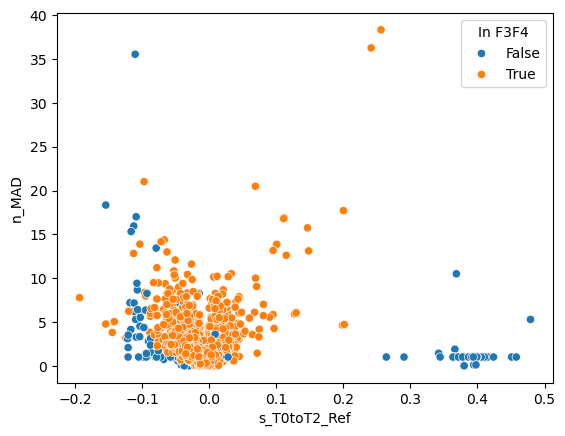

In [16]:
sns.scatterplot(data=s_300_MAD, x='s_T0toT2_Ref', y='n_MAD', hue='In F3F4')

Interestingly / surprisingly, the most extreme outliers among F3F4 mutants are only associated with an intermediate level of resistance. If their deviation is really due to some unseen resistance-conferring secondary mutation, it would likely indicate a mixed population.

Keeping only the F3F4 mutants, are outliers shared within transformation ("Bio") replicates?

In [19]:
s_300_MAD_F3F4 = s_300_MAD[s_300_MAD['In F3F4'] == True].copy().reset_index(drop=True)

<Axes: xlabel='s_T0toT2_Ref', ylabel='n_MAD'>

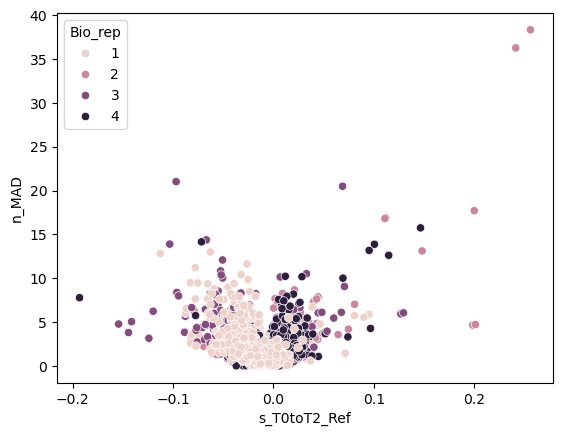

In [20]:
sns.scatterplot(data=s_300_MAD_F3F4, x='s_T0toT2_Ref', y='n_MAD', hue='Bio_rep')

They definitely are, but maybe not as much as initially suspected.

What does the distribution of n_MAD values look like?

In [23]:
# Computing 95th, 97.5 and 99 percentiles
n_MAD_95 = np.nanpercentile(s_300_MAD['n_MAD'], 95)
n_MAD_975 = np.nanpercentile(s_300_MAD['n_MAD'], 97.5)
n_MAD_99 = np.nanpercentile(s_300_MAD['n_MAD'], 99)

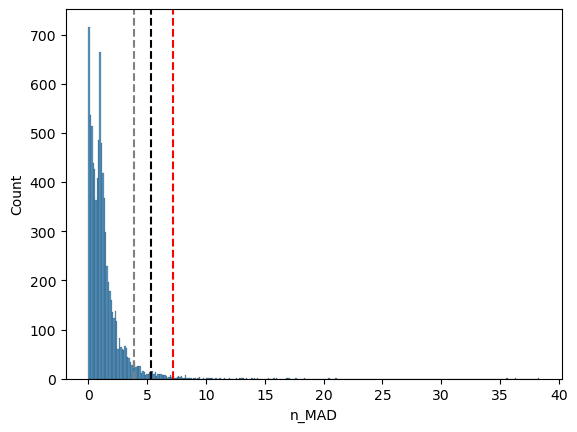

In [24]:
sns.histplot(data=s_300_MAD, x='n_MAD')
plt.axvline(x=n_MAD_95, linestyle='--', c='grey')
plt.axvline(x=n_MAD_975, linestyle='--', c='black')
plt.axvline(x=n_MAD_99, linestyle='--', c='red')

What does the previous plot look like with only replicates with MAD < 3.89?

<Axes: xlabel='s_T0toT2_Ref', ylabel='n_MAD'>

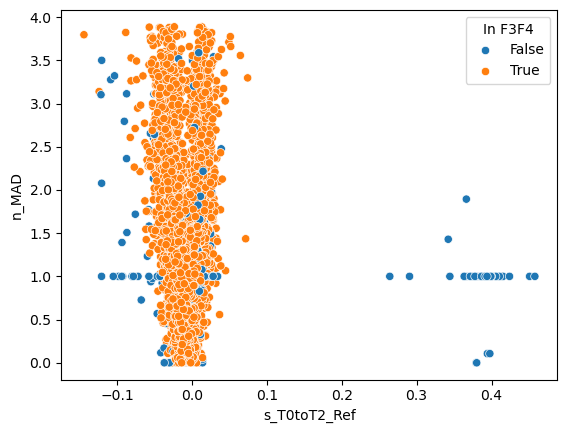

In [26]:
s_300_MAD_filtered = s_300_MAD[s_300_MAD['n_MAD'] <= n_MAD_95].copy().reset_index(drop=True)
s_300_MAD_removed = s_300_MAD[s_300_MAD['n_MAD'] > n_MAD_95].copy().reset_index(drop=True)

sns.scatterplot(data=s_300_MAD_filtered, x='s_T0toT2_Ref', y='n_MAD', hue='In F3F4')

### Is this removal of outliers justified?

#### What fraction of removed outliers are part of a pair of culture replicate observations which are both removed?

For each removed observation, let's check iteratively whether the corresponding culture replicate (same transformation replicate) has also been removed.

In [30]:
s_300_MAD_removed['Pair_removed'] = 'Problem'

for row in range(s_300_MAD_removed.shape[0]):
    current_genotype = s_300_MAD_removed.at[row, 'Genotype']
    current_transfo = s_300_MAD_removed.at[row, 'Bio_rep']
    #current_culture = s_300_MAD_removed.at[row, 'Tech_rep']

    genotype_subset = s_300_MAD_removed[s_300_MAD_removed['Genotype'] == current_genotype].copy().reset_index(drop=True)
    transfo_subset = genotype_subset[genotype_subset['Bio_rep'] == current_transfo].copy().reset_index(drop=True)

    # If the resulting df has two rows, the pair has been removed
    if transfo_subset.shape[0] == 2:
        s_300_MAD_removed.at[row, 'Pair_removed'] = 'Yes'

    elif transfo_subset.shape[0] == 1:
        s_300_MAD_removed.at[row, 'Pair_removed'] = 'No'

    else:
        raise Exception('There should be either one or two observations!')

How often is the full pair removed?

In [32]:
percent_pair = (np.sum(s_300_MAD_removed['Pair_removed'] == 'Yes')/s_300_MAD_removed.shape[0])/100

print(f'{percent_pair}% of removed outliers are part of a pair which is fully removed')

0.0013711583924349883% of removed outliers are part of a pair which is fully removed


This removal of outliers is clearly not adequate, since it almost only removes singletons (and the fraction of pairs is barely improved by using a more stringent threshold).

What we want to remove is outlier selection coefficient estimates due to secondary mutations outside the sequenced region - which would most likely be shared within a transformation replicate. A better approach may be to directly use the absolute deviations from the median, without scaling them relative to MAD (which seems inadequate due to how close to 0 most values are).

### Better approach: performing this outlier removal ONLY for genotypes which have an outlier standard deviation

In [36]:
# Adding the standard deviation to the df
s_mean = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'],
                                                                                                as_index=False).mean()
s_mean = s_mean.rename(columns={'s_T0toT2_Ref': 'Mean_s'})

s_std = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'],
                                                                                               as_index=False).std()
s_std = s_std.rename(columns={'s_T0toT2_Ref': 'Std_s'})

s_min = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'],
                                                                                               as_index=False).min()
s_min = s_min.rename(columns={'s_T0toT2_Ref': 'Min_s'})

s_max = s_300_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'],
                                                                                               as_index=False).max()
s_max = s_max.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_out_bypos = pd.merge(s_mean, s_std, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')
s_out_bypos = pd.merge(s_out_bypos, s_min, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')
s_out_bypos = pd.merge(s_out_bypos, s_max, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')

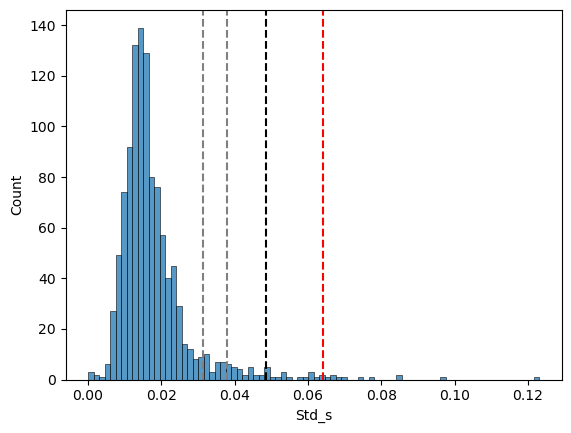

In [37]:
# Plotting the distribution of standard deviations, with 95th, 97.5th and 99th percentiles
std_925 = np.nanpercentile(s_out_bypos['Std_s'], 92.5)
std_95 = np.nanpercentile(s_out_bypos['Std_s'], 95)
std_975 = np.nanpercentile(s_out_bypos['Std_s'], 97.5)
std_99 = np.nanpercentile(s_out_bypos['Std_s'], 99)

sns.histplot(data=s_out_bypos, x='Std_s')
plt.axvline(x=std_925, linestyle='--', c='grey')
plt.axvline(x=std_95, linestyle='--', c='grey')
plt.axvline(x=std_975, linestyle='--', c='black')
plt.axvline(x=std_99, linestyle='--', c='red')

Let's try removing outliers according to n_MAD, but only within the genotypes which have an outlier Std (Top 5%)

In [39]:
out_mut_df = s_out_bypos[s_out_bypos['Std_s'] >= std_95].copy().reset_index(drop=True)
mut_to_filter = out_mut_df['Genotype'].unique()

In [40]:
out_mut_df[out_mut_df['In F3F4'] == True].sort_values(by='Std_s', ascending=False)

,Genotype,Position,In F3F4,Mutation type,Mean_s,Std_s,Min_s,Max_s
9,I-203_1nt_-toG,203,True,Insertion,0.049782,0.123130,-0.024169,0.256222
19,S-172_1nt_GtoC,172,True,Substitution,0.053810,0.096414,-0.028066,0.201384
54,S-78_1nt_GtoA,78,True,Substitution,0.038389,0.085327,-0.020991,0.200191
3,I-109_1nt_-toT,109,True,Insertion,0.019164,0.069974,-0.031999,0.146623
14,S-132_1nt_TtoA,132,True,Substitution,0.022836,0.067571,-0.046864,0.129630
18,S-160_1nt_TtoC,160,True,Substitution,-0.035604,0.067398,-0.193245,0.015813
13,S-131_1nt_TtoC,131,True,Substitution,-0.020309,0.064889,-0.154276,0.044779
6,I-118_1nt_-toC,118,True,Insertion,-0.047485,0.061338,-0.144451,0.007022
22,S-192_1nt_AtoG,192,True,Substitution,0.018844,0.057578,-0.022842,0.111904
4,I-116_1nt_-toC,116,True,Insertion,-0.020798,0.053808,-0.119888,0.038034


In [41]:
not_filtered =  s_300_MAD[~s_300_MAD['Genotype'].isin(mut_to_filter)].copy()
to_filter = s_300_MAD[s_300_MAD['Genotype'].isin(mut_to_filter)].copy()
to_filter['To_remove'] = to_filter['n_MAD'] > n_MAD_95

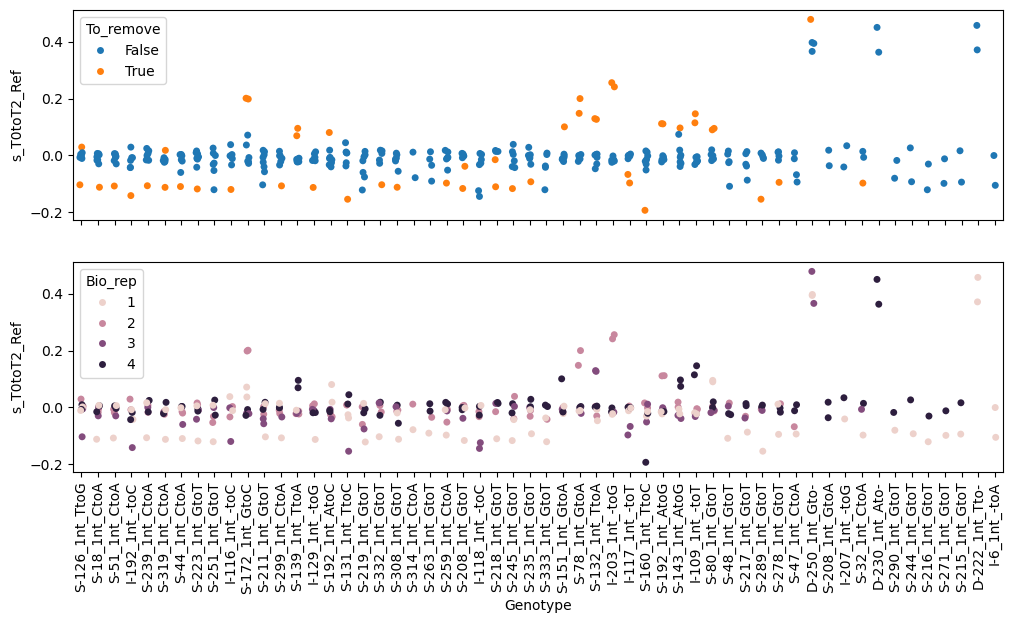

In [42]:
# All variants

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sns.stripplot(data=to_filter, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90)

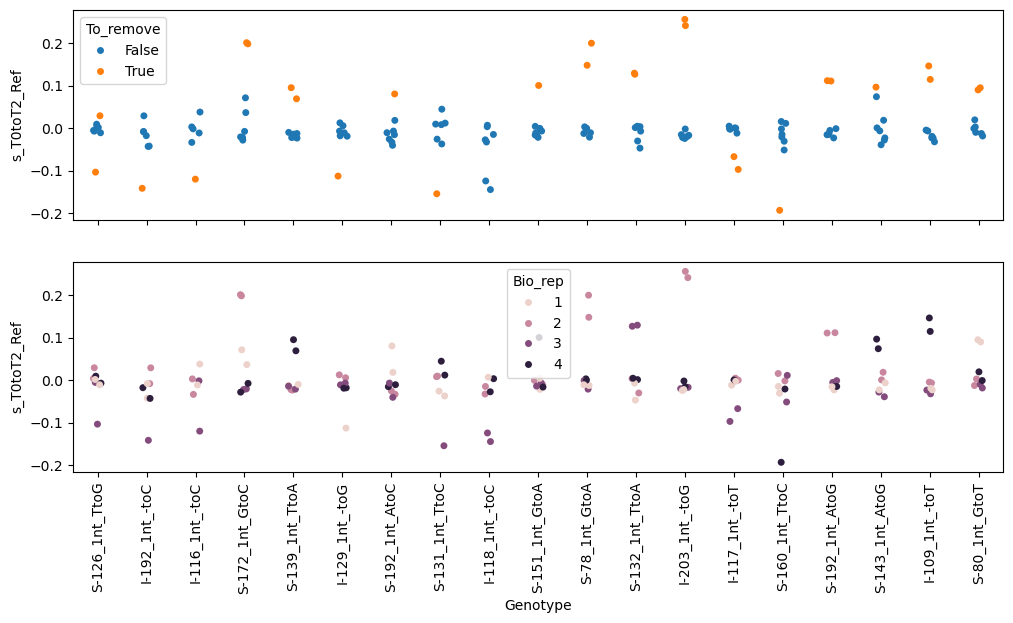

In [43]:
# Only mutations within the F3F4 region

to_filter_F3F4 = to_filter[to_filter['In F3F4'] == True].copy().reset_index(drop=True)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sns.stripplot(data=to_filter_F3F4, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_F3F4, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90)

The outlier positive selection coefficients are almost always removed by pair (both culture of the same transformation), so this seems to work as intended!

When negative selection coefficients are identified as outliers, they almost always come from the same sequencing library (one culture of 3 when within F3F4, and one culture of 1 when outside of it). These outliers thus seem to be due to sequencing variation.

In [46]:
# Assembling the dataset WITHOUT outliers
out_filtered = to_filter[to_filter['To_remove'] == False].copy().reset_index(drop=True)
out_filtered = out_filtered.drop(columns=['To_remove'])
s_no_out = pd.concat([not_filtered, out_filtered]).reset_index(drop=True)

### Final estimations of fitness effects

#### Let's first plot the selection coefficients for all mutations (only F3F4 region) 

In [49]:
# Recomputing the medians, + min and max s for each genotype
# The 'To_ignore' samples are now ignored
s_ignored = s_no_out[s_no_out['To_ignore'] == False].copy().reset_index(drop=True)

median_s = s_ignored[['Genotype', 's_T0toT2_Ref']].groupby(by='Genotype', as_index=False).median()
median_s = median_s.rename(columns={'s_T0toT2_Ref': 'Median_s_ignored'})
min_s = s_ignored[['Genotype', 's_T0toT2_Ref']].groupby(by='Genotype', as_index=False).min()
min_s = min_s.rename(columns={'s_T0toT2_Ref': 'Min_s_ignored'})
max_s = s_ignored[['Genotype', 's_T0toT2_Ref']].groupby(by='Genotype', as_index=False).max()
max_s = max_s.rename(columns={'s_T0toT2_Ref': 'Max_s_ignored'})

s_no_out = pd.merge(s_no_out, median_s, on=['Genotype'], how='left')
s_no_out = pd.merge(s_no_out, min_s, on=['Genotype'], how='left')
s_no_out = pd.merge(s_no_out, max_s, on=['Genotype'], how='left')

In [50]:
# Converting the mutation position and adding a column specifying the new base
s_no_out['FCY1_position'] = s_no_out['Position'] - 205 + 1*(s_no_out['Mutation type'] == 'Insertion')
s_no_out['New_nt'] = s_no_out['Genotype'].apply(lambda x: x.split('to')[1])
# 1 is added in the case of insertions, because their positions where initially defined as
# "the base to the right of which the nt is inserted", rather than the position of
# the inserted nt

In [51]:
# Version of the df without duplicates
s_medians = s_no_out.drop(columns=['Alias', 'Bio_rep', 'Tech_rep', 'To_ignore', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref',
                                   's_T0toT3_Ref', 'Abs_med_s_T0toT2', 'MAD_s_T0toT2', 'n_MAD']).copy()
s_medians = s_medians.drop_duplicates().reset_index(drop=True)

In [52]:
# Defining a palette for the different types of mutations
mut_palette = {'Substitution': cm.tab10.colors[9], 
               'Insertion': cm.tab20b.colors[1],
               'Deletion': cm.tab10.colors[3]}

In [53]:
# Individually plotting all the selection coefficients
s_F3F4 = s_no_out[s_no_out['In F3F4'] == True].copy().reset_index(drop=True)
s_F3F4 = s_F3F4[s_F3F4['To_ignore'] == False].copy().reset_index(drop=True)

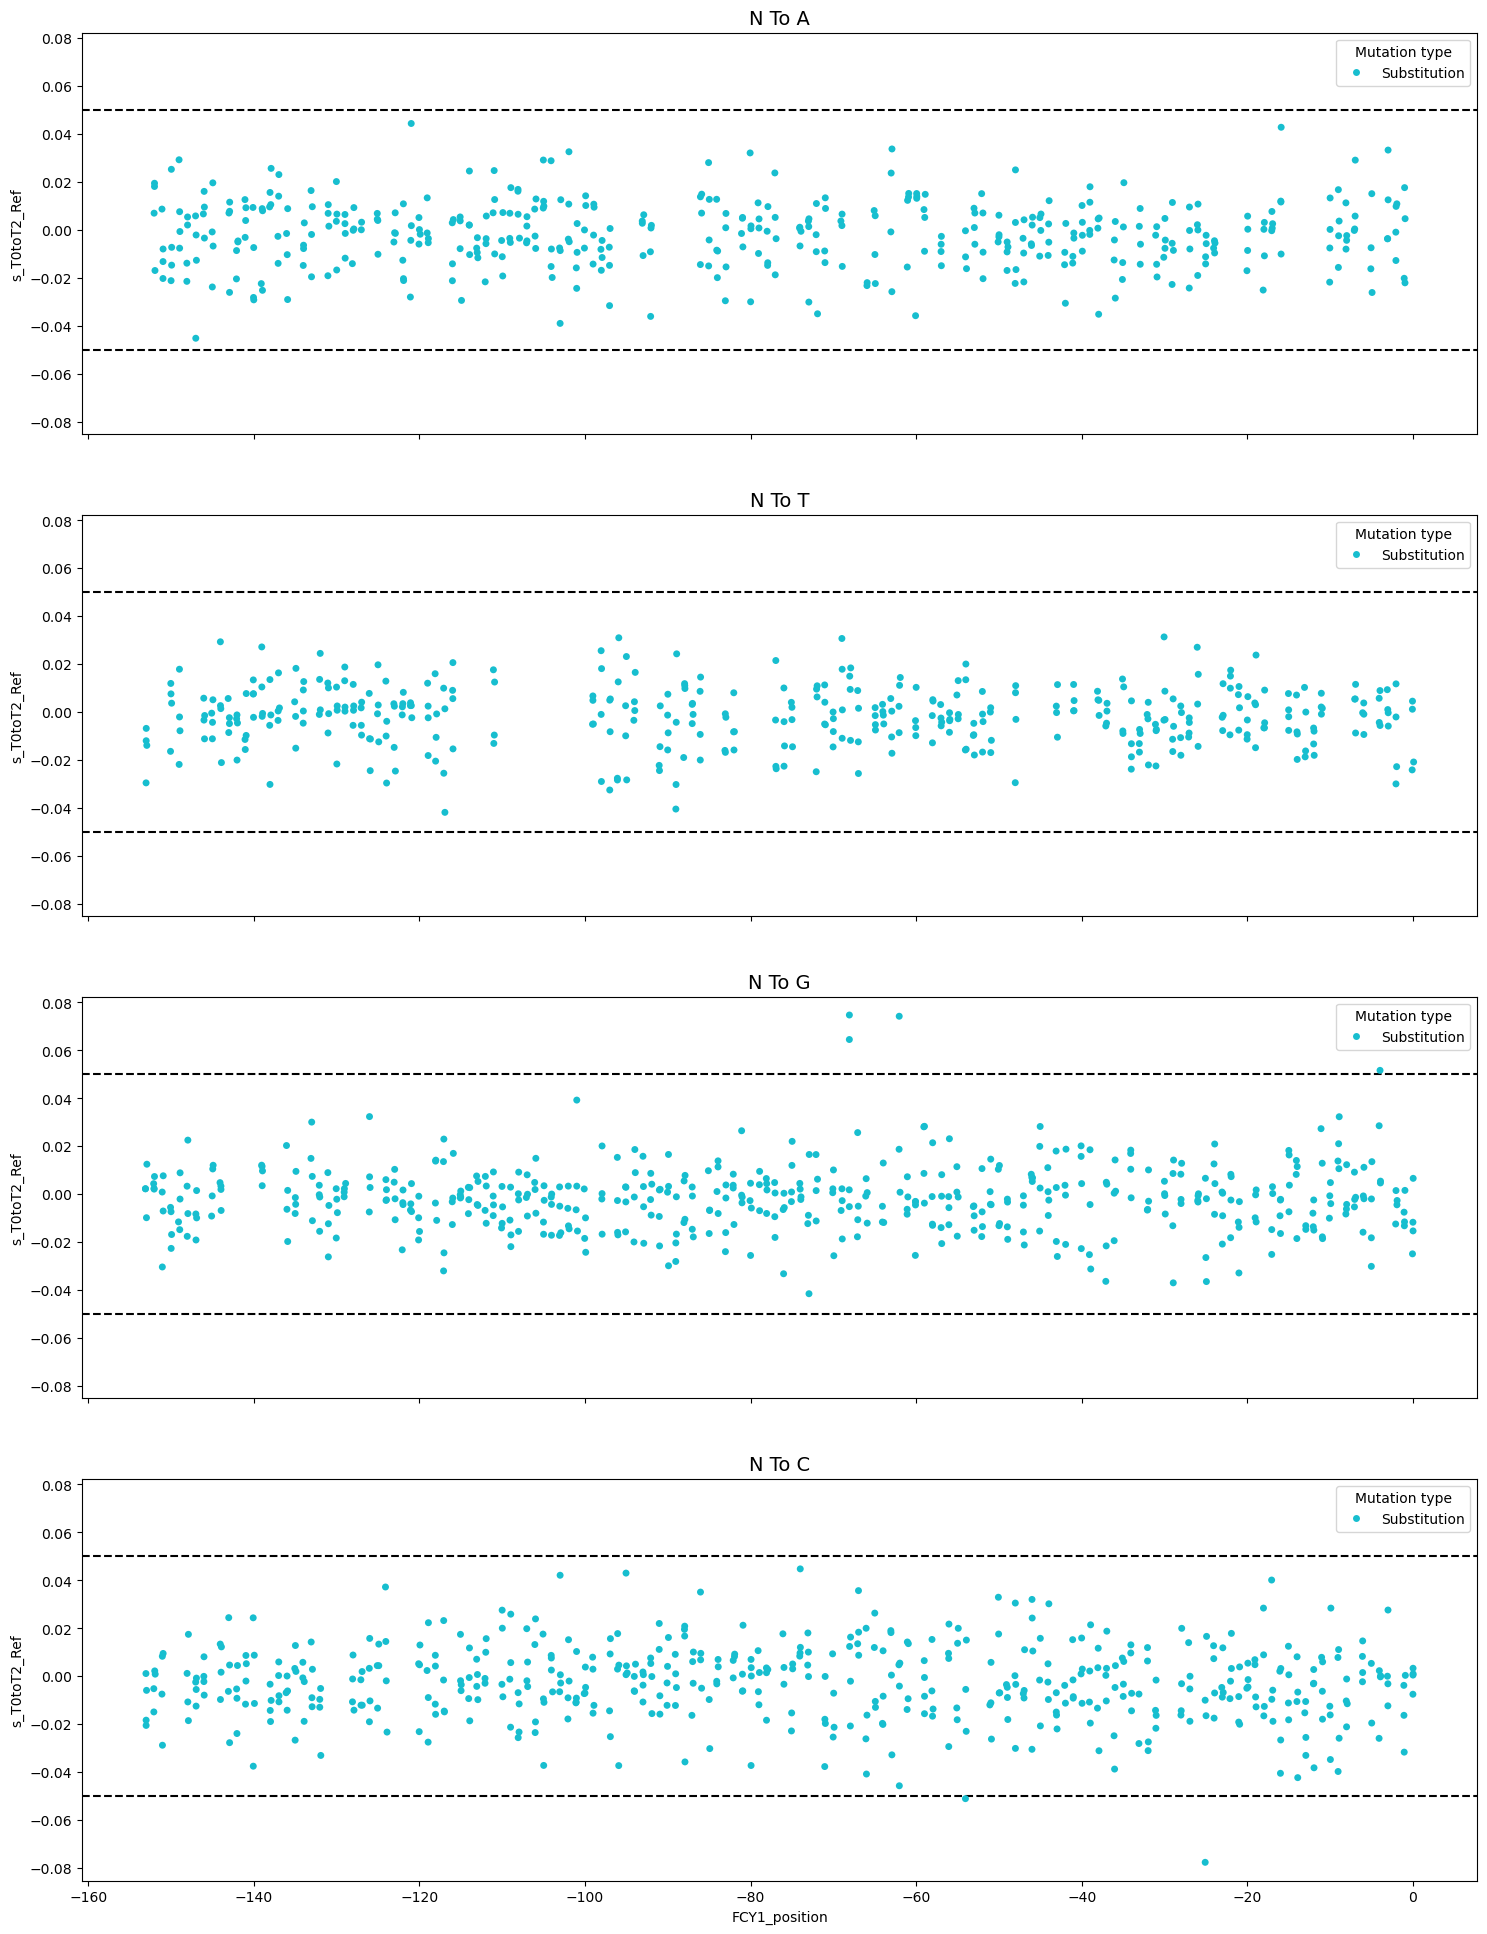

In [54]:
# First figure: Substitutions
# from top to bottom: A, T, G, C

s_F3F4_sub = s_F3F4[s_F3F4['Mutation type'] == 'Substitution'].copy().reset_index(drop=True)

fig, axs = plt.subplots(4, 1, figsize=(18, 24), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'A'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[0], palette=mut_palette, native_scale=True)
axs[0].set_title('N To A', fontsize=14)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'T'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[1], palette=mut_palette, native_scale=True)
axs[1].set_title('N To T', fontsize=14)


sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'G'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[2], palette=mut_palette, native_scale=True)
axs[2].set_title('N To G', fontsize=14)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'C'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[3], palette=mut_palette, native_scale=True)
axs[3].set_title('N To C', fontsize=14)

for k in range(4):
    axs[k].axhline(y=0.05, linestyle='--', c='black')
    axs[k].axhline(y=-0.05, linestyle='--', c='black')

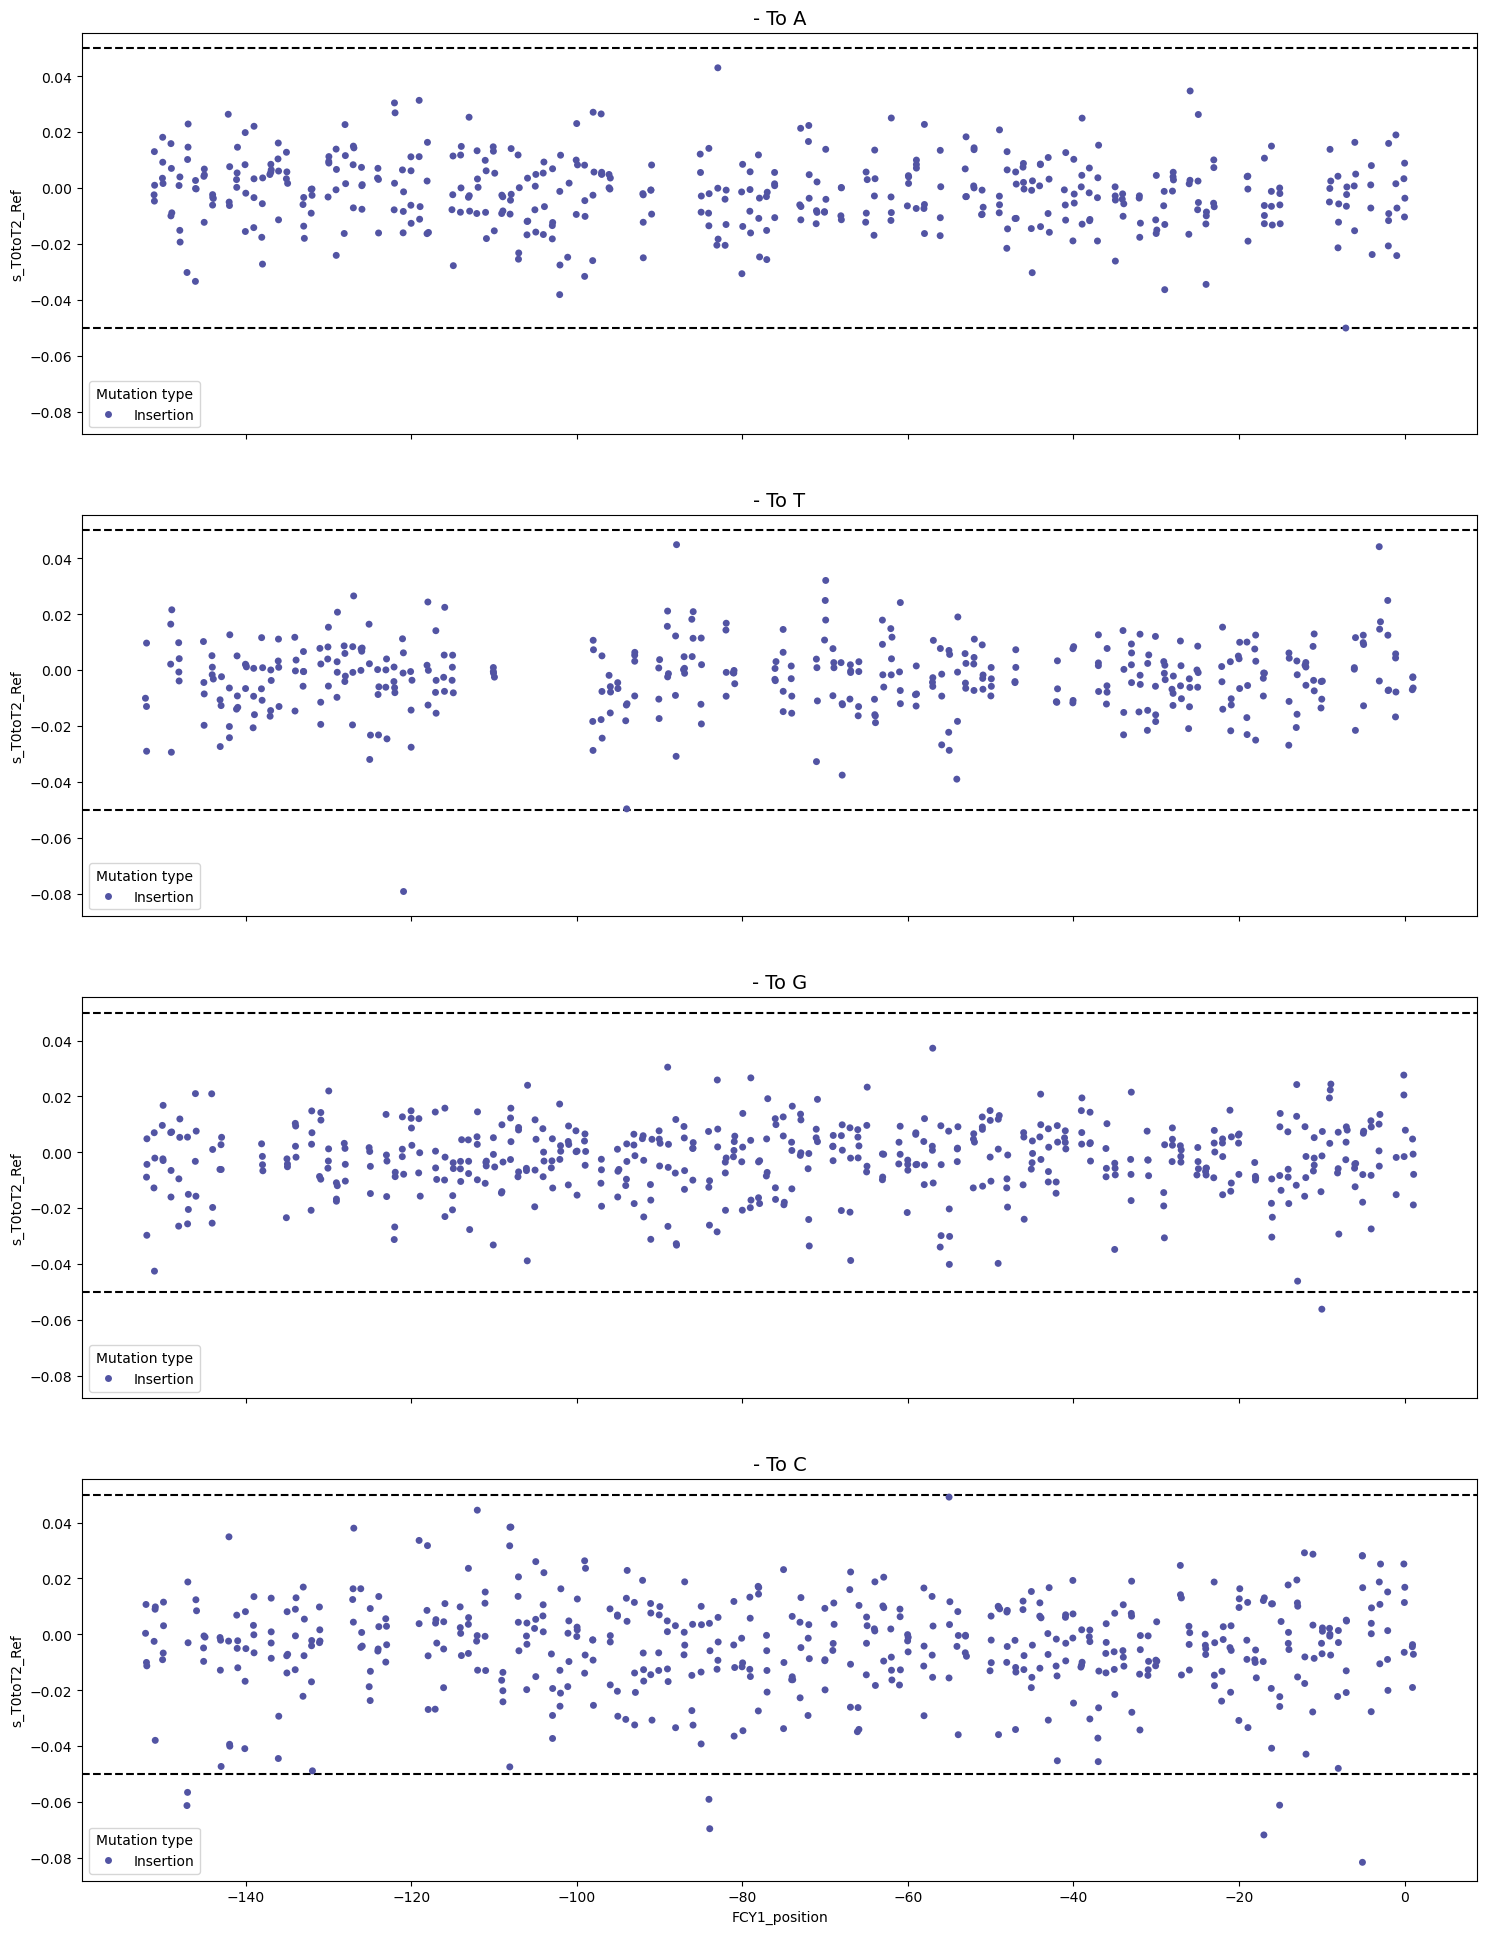

In [55]:
# Second figure: Insertions
# from top to bottom: A, T, G, C

s_F3F4_ins = s_F3F4[s_F3F4['Mutation type'] == 'Insertion'].copy().reset_index(drop=True)

fig, axs = plt.subplots(4, 1, figsize=(18, 24), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'A'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[0], palette=mut_palette, native_scale=True)
axs[0].set_title('- To A', fontsize=14)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'T'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[1], palette=mut_palette, native_scale=True)
axs[1].set_title('- To T', fontsize=14)


sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'G'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[2], palette=mut_palette, native_scale=True)
axs[2].set_title('- To G', fontsize=14)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'C'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[3], palette=mut_palette, native_scale=True)
axs[3].set_title('- To C', fontsize=14)

for k in range(4):
    axs[k].axhline(y=0.05, linestyle='--', c='black')
    axs[k].axhline(y=-0.05, linestyle='--', c='black')

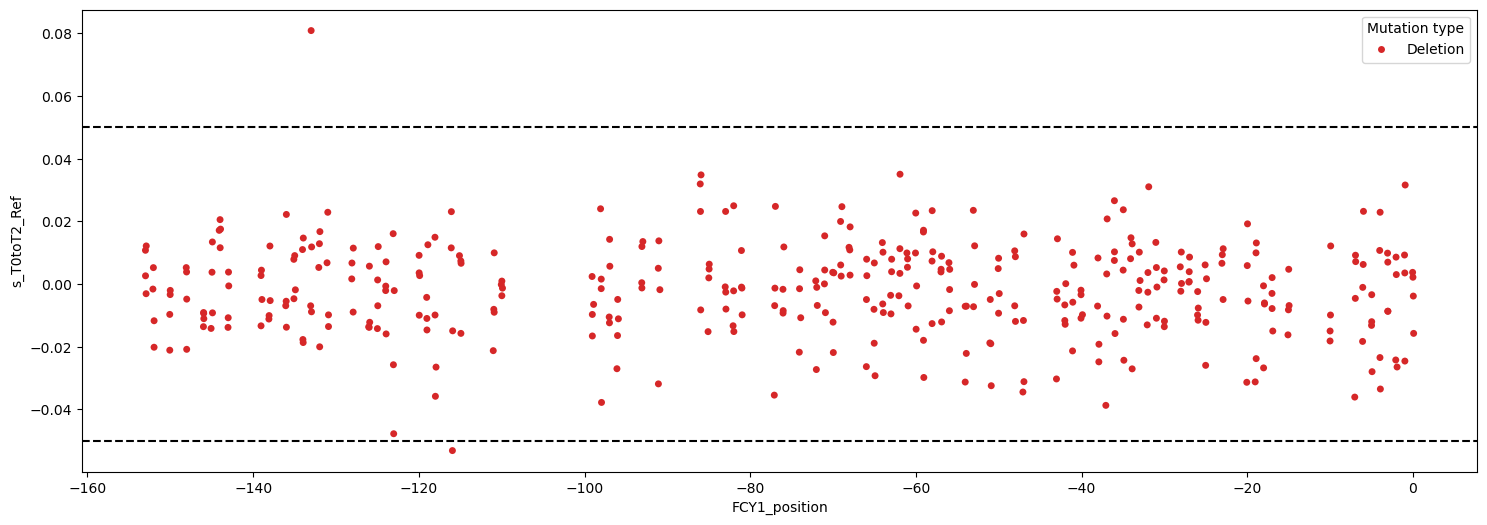

In [56]:
# Third figure: Deletions

s_F3F4_del = s_F3F4[s_F3F4['Mutation type'] == 'Deletion'].copy().reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(18, 6), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_del, x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=ax, palette=mut_palette, native_scale=True)

ax.axhline(y=0.05, linestyle='--', c='black')
ax.axhline(y=-0.05, linestyle='--', c='black')

We seem to have great coverage of the mutations of interest - even after the filtering steps. There is also no clear indication that any of the mutation has an effect (significantly different from 0).

It seems like we would have been able to measure confidently any fitness difference of 5% or more, which is a good resolution. There were, however, no such effects in this experiment.

#### Testing if there are significant ("measurable") fitness effects: t-test

Now that an outlier removal step has been performed, we can use a t-test (with Benjamini-Hochberg correction at FDR=5%) to assess whether some mutations have significant fitness effects

In [61]:
s_med_F3F4 = s_medians[s_medians['In F3F4'] == True].copy().reset_index(drop=True)

In [62]:
s_med_F3F4['not_zero_p-val'] = np.nan
s_med_F3F4['n_observed'] = np.nan

for row in range(s_med_F3F4.shape[0]):
    current_mut = s_med_F3F4.at[row, 'Genotype']
    data_subset = s_F3F4[s_F3F4['Genotype'] == current_mut].copy().reset_index(drop=True)
    n_obs = data_subset.shape[0]
    s_med_F3F4.at[row, 'n_observed'] = n_obs
    t_test = stats.ttest_1samp(data_subset['s_T0toT2_Ref'], 0, nan_policy='omit')
    s_med_F3F4.at[row, 'not_zero_p-val'] = t_test.pvalue

In [63]:
s_med_F3F4['not_zero_FDR'] = stats.false_discovery_control(s_med_F3F4['not_zero_p-val'])

In [64]:
s_med_F3F4.sort_values(by=['not_zero_FDR'], ascending=True)

,Genotype,Position,In F3F4,Mutation type,Median_s_T0toT2,Median_s_ignored,Min_s_ignored,Max_s_ignored,FCY1_position,New_nt,not_zero_p-val,n_observed,not_zero_FDR
582,I-180_1nt_-toG,180,True,Insertion,-0.007500,-0.006313,-0.008120,-0.005612,-24,G,0.001493,4.0,0.497047
674,I-95_1nt_-toC,95,True,Insertion,-0.020515,-0.018292,-0.024117,-0.013590,-109,C,0.003898,4.0,0.497047
247,D-61_1nt_Ato-,61,True,Deletion,0.000850,0.017325,0.011576,0.020547,-144,-,0.002961,4.0,0.497047
448,I-75_1nt_-toG,75,True,Insertion,-0.014341,-0.014341,-0.017508,-0.010908,-129,G,0.003322,4.0,0.497047
75,D-59_1nt_Gto-,59,True,Deletion,-0.012354,-0.010229,-0.013631,-0.009116,-146,-,0.001897,4.0,0.497047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,S-57_1nt_TtoG,57,True,Substitution,-0.004593,-0.002391,-0.017598,0.022532,-148,G,0.996770,4.0,0.999833
638,S-74_1nt_CtoA,74,True,Substitution,0.000967,0.004257,-0.019090,0.010570,-131,A,0.999833,4.0,0.999833
925,I-71_1nt_-toT,71,True,Insertion,-0.003118,-0.000473,-0.005727,0.006679,-133,T,0.999617,4.0,0.999833
370,S-134_1nt_GtoA,134,True,Substitution,0.000110,0.000110,-0.013612,0.013413,-71,A,0.999404,4.0,0.999833


In [65]:
s_med_F3F4[s_med_F3F4['not_zero_FDR'] < 0.92]

,Genotype,Position,In F3F4,Mutation type,Median_s_T0toT2,Median_s_ignored,Min_s_ignored,Max_s_ignored,FCY1_position,New_nt,not_zero_p-val,n_observed,not_zero_FDR
0,I-94_1nt_-toT,94,True,Insertion,-0.001975,-0.000763,-0.002475,0.000961,-110,T,0.363973,4.0,0.916193
2,I-111_1nt_-toC,111,True,Insertion,-0.017276,-0.017284,-0.032395,0.011443,-93,C,0.231278,4.0,0.915612
5,D-79_1nt_Ato-,79,True,Deletion,-0.012957,-0.012957,-0.013844,0.005691,-126,-,0.170858,4.0,0.902337
6,S-89_1nt_CtoA,89,True,Substitution,-0.012920,-0.005559,-0.021173,0.004342,-116,A,0.349904,4.0,0.915612
8,I-100_1nt_-toC,100,True,Insertion,0.003765,0.008604,0.000923,0.022080,-104,C,0.110237,4.0,0.902337
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,S-151_1nt_GtoA,151,True,Substitution,-0.008945,-0.011222,-0.016141,-0.000326,-54,A,0.186914,3.0,0.912212
1013,S-143_1nt_AtoG,143,True,Substitution,-0.002696,0.018723,0.000800,0.074207,-62,G,0.292952,3.0,0.915612
1014,I-109_1nt_-toT,109,True,Insertion,-0.012872,-0.005507,-0.006562,-0.004452,-95,T,0.120498,2.0,0.902337
1016,S-172_1nt_GtoC,172,True,Substitution,0.014663,-0.017753,-0.028066,-0.007440,-33,C,0.335030,2.0,0.915612


In [66]:
s_med_F3F4[s_med_F3F4['not_zero_p-val'] < 0.05].sort_values(by='not_zero_p-val')

,Genotype,Position,In F3F4,Mutation type,Median_s_T0toT2,Median_s_ignored,Min_s_ignored,Max_s_ignored,FCY1_position,New_nt,not_zero_p-val,n_observed,not_zero_FDR
582,I-180_1nt_-toG,180,True,Insertion,-0.007500,-0.006313,-0.008120,-0.005612,-24,G,0.001493,4.0,0.497047
344,S-159_1nt_TtoG,159,True,Substitution,0.006047,0.006888,0.005288,0.008296,-46,G,0.001561,4.0,0.497047
75,D-59_1nt_Gto-,59,True,Deletion,-0.012354,-0.010229,-0.013631,-0.009116,-146,-,0.001897,4.0,0.497047
247,D-61_1nt_Ato-,61,True,Deletion,0.000850,0.017325,0.011576,0.020547,-144,-,0.002961,4.0,0.497047
606,I-140_1nt_-toT,140,True,Insertion,-0.014265,-0.016131,-0.018771,-0.010395,-64,T,0.003218,4.0,0.497047
448,I-75_1nt_-toG,75,True,Insertion,-0.014341,-0.014341,-0.017508,-0.010908,-129,G,0.003322,4.0,0.497047
709,I-67_1nt_-toA,67,True,Insertion,-0.000357,0.006108,0.004869,0.008525,-137,A,0.003880,4.0,0.497047
674,I-95_1nt_-toC,95,True,Insertion,-0.020515,-0.018292,-0.024117,-0.013590,-109,C,0.003898,4.0,0.497047
922,S-181_1nt_TtoA,181,True,Substitution,-0.004971,-0.006506,-0.009589,-0.004496,-24,A,0.009450,4.0,0.902337
515,I-186_1nt_-toG,186,True,Insertion,-0.009531,-0.008886,-0.009911,-0.003656,-18,G,0.011677,4.0,0.902337


Not even one selection coefficient is significantly different from 0 at FDR = 0.05!

The t-test is clearly underpowered with only four datapoints. Let's try a different approach!

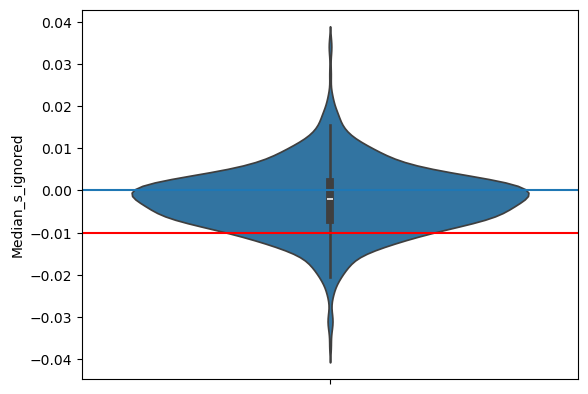

In [69]:
sns.violinplot(s_med_F3F4['Median_s_ignored'])
plt.axhline(y=0)
plt.axhline(y=-0.01, c='red')

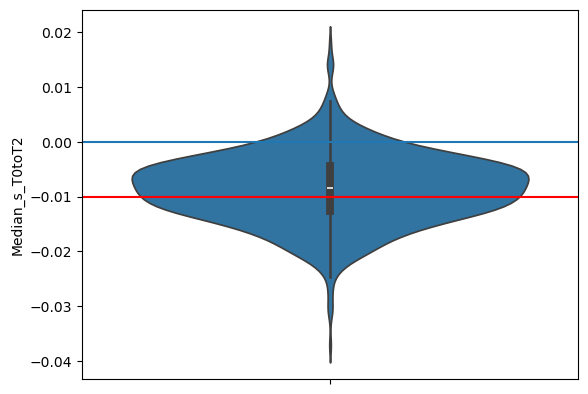

In [70]:
sns.violinplot(s_med_F3F4['Median_s_T0toT2'])
plt.axhline(y=0)
plt.axhline(y=-0.01, c='red')

The shift observed between the two medians s seem to justify ignoring the four 'to_ignore' samples

#### Better approach: bootstrapping to generate a 95% confidence interval

In [77]:
# Setting up a random number generator
rng_boot = np.random.default_rng()

In [74]:
# Performing the bootstrapping
n_iterations = 5000
all_genotypes = list(s_med_F3F4['Genotype'].unique())

for iter_n in range(n_iterations):
    median_s = pd.DataFrame(index=all_genotypes, columns=['Median_s'])

    # Sampling n values for each genotype and computing a median
    for mutation in all_genotypes:
        mut_subset = s_F3F4[s_F3F4['Genotype'] == mutation].copy().reset_index(drop=True)
        sampled_vals = rng_boot.choice(mut_subset['s_T0toT2_Ref'].values, size=mut_subset.shape[0], replace=True)
        sampled_med = np.median(sampled_vals)
        median_s.at[mutation, 'Median_s'] = sampled_med

    # Keeping the new medians for future percentile calculations
    medians_current = median_s['Median_s'].to_numpy().reshape(len(all_genotypes), 1)

    if iter_n == 0:
        medians_boot = medians_current.copy()
    
    else:
        medians_boot = np.concatenate((medians_boot, medians_current), axis=1)

    if (iter_n + 1) % 100 == 0:
        print(f'Done with iteration {iter_n+1}')

# Once all the sampling has been performed, the relevant percentiles are extracted
s_bootstrapped = pd.DataFrame(columns=['Genotype', 'Median_s', 'bot_2_5percent', 'top_97_5percent'])
s_bootstrapped['Genotype'] = all_genotypes
s_bootstrapped['Median_s'] = np.median(medians_boot, axis=1)
s_bootstrapped['bot_2_5percent'] = np.percentile(medians_boot, 2.5, axis=1)
s_bootstrapped['top_97_5percent'] = np.percentile(medians_boot, 97.5, axis=1)

# This was not useful with so few replicates

Done with iteration 100
Done with iteration 200
Done with iteration 300
Done with iteration 400
Done with iteration 500
Done with iteration 600
Done with iteration 700
Done with iteration 800
Done with iteration 900
Done with iteration 1000
Done with iteration 1100
Done with iteration 1200
Done with iteration 1300
Done with iteration 1400
Done with iteration 1500
Done with iteration 1600
Done with iteration 1700
Done with iteration 1800
Done with iteration 1900
Done with iteration 2000
Done with iteration 2100
Done with iteration 2200
Done with iteration 2300
Done with iteration 2400
Done with iteration 2500
Done with iteration 2600
Done with iteration 2700
Done with iteration 2800
Done with iteration 2900
Done with iteration 3000
Done with iteration 3100
Done with iteration 3200
Done with iteration 3300
Done with iteration 3400
Done with iteration 3500
Done with iteration 3600
Done with iteration 3700
Done with iteration 3800
Done with iteration 3900
Done with iteration 4000
Done with

In [389]:
np.median(s_bootstrapped['top_97_5percent'] - s_bootstrapped['bot_2_5percent'])

0.0250955384334331

Since the median width of measurement intervals is 0.025, let's consider 0.0125 as the cutoff to be different from 0:

In [391]:
s_different = s_bootstrapped[(s_bootstrapped['bot_2_5percent'] > 0.0125) | (s_bootstrapped['top_97_5percent'] < -0.0125)].copy().reset_index(drop=True)
s_not_zero = s_different['Genotype'].unique()

In [393]:
s_different

,Genotype,Median_s,bot_2_5percent,top_97_5percent
0,I-68_1nt_-toC,-0.036846,-0.044411,-0.029281
1,I-167_1nt_-toC,-0.031694,-0.045532,-0.013129
2,I-95_1nt_-toC,-0.018292,-0.024117,-0.01359
3,S-139_1nt_TtoA,-0.022586,-0.023206,-0.021966
4,S-192_1nt_AtoG,-0.013923,-0.0147,-0.013146


In [395]:
diff_all_data = pd.merge(s_different, s_med_F3F4, on='Genotype', how='left')

In [397]:
diff_all_data

,Genotype,Median_s,bot_2_5percent,top_97_5percent,Position,In F3F4,Mutation type,Median_s_T0toT2,Median_s_ignored,Min_s_ignored,Max_s_ignored,FCY1_position,New_nt,not_zero_p-val,n_observed,not_zero_FDR
0,I-68_1nt_-toC,-0.036846,-0.044411,-0.029281,68,True,Insertion,-0.019729,-0.036846,-0.044411,-0.029281,-136,C,0.128918,2.0,0.902337
1,I-167_1nt_-toC,-0.031694,-0.045532,-0.013129,167,True,Insertion,-0.037116,-0.031694,-0.045532,-0.013129,-37,C,0.022385,4.0,0.902337
2,I-95_1nt_-toC,-0.018292,-0.024117,-0.01359,95,True,Insertion,-0.020515,-0.018292,-0.024117,-0.013590,-109,C,0.003898,4.0,0.497047
3,S-139_1nt_TtoA,-0.022586,-0.023206,-0.021966,139,True,Substitution,-0.013245,-0.022586,-0.023206,-0.021966,-66,A,0.017470,2.0,0.902337
4,S-192_1nt_AtoG,-0.013923,-0.0147,-0.013146,192,True,Substitution,-0.009194,-0.013923,-0.014700,-0.013146,-13,G,0.035489,2.0,0.902337


It appears that bootstrapping was completely useless: the values are exactly the min and max values from the measurements. Was that to be expected? Maybe, considering the there are 3-4 datapoints per estimated selection coefficient.

Among these "significant" mutations, what do the correlations between (unbiased) replicates look like?

In [400]:
s_F3F4_diff = s_F3F4[s_F3F4['Genotype'].isin(s_not_zero)].copy().reset_index(drop=True)

# pivoted df
s_diff_bysamp = s_F3F4_diff[['Alias', 'Genotype', 's_T0toT2_Ref']].copy().pivot(columns='Alias', index='Genotype', values='s_T0toT2_Ref')

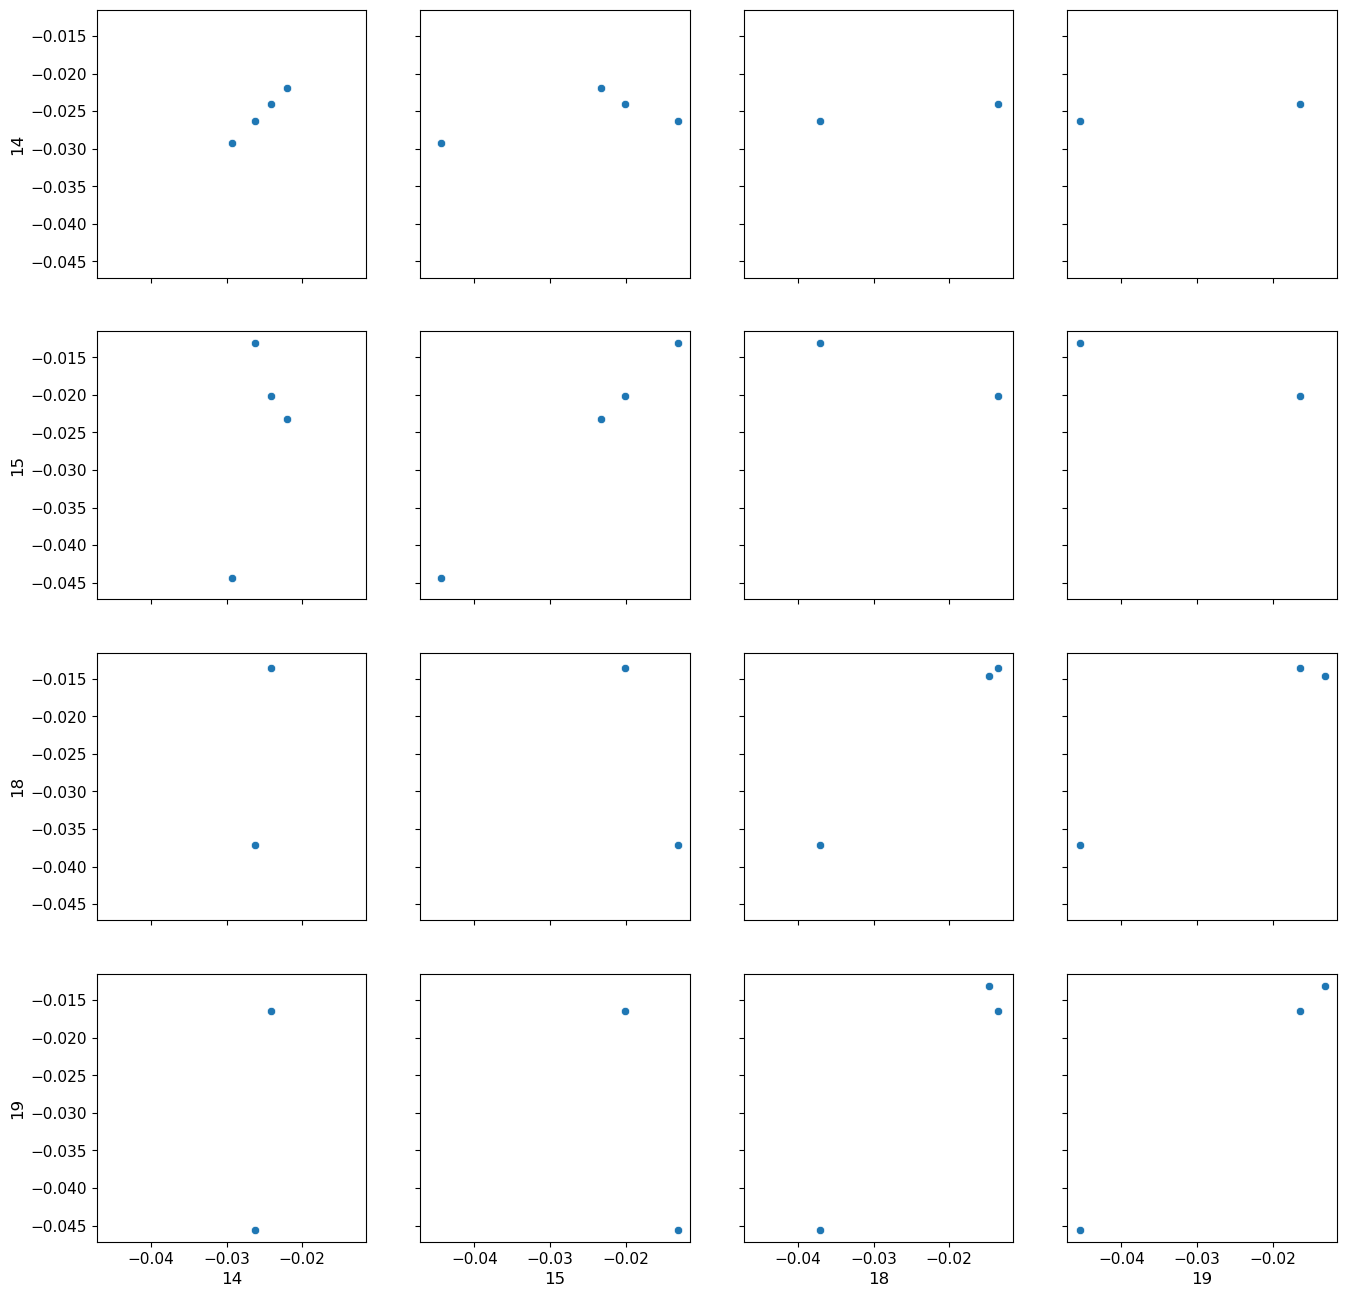

In [402]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)
row_fig = 0
col_fig = 0

for lib_a in np.sort(s_F3F4_diff['Alias'].unique()):

    for lib_b in np.sort(s_F3F4_diff['Alias'].unique()):

        if lib_a == lib_b:
            data_subset = s_diff_bysamp[[lib_a]].dropna().reset_index(drop=True)

        elif lib_a != lib_b:
            data_subset = s_diff_bysamp[[lib_a, lib_b]].dropna().reset_index(drop=True)

        # Computing spearman corr
        spearman_calc = stats.spearmanr(data_subset[lib_a], data_subset[lib_b])

        # Plotting the scatter
        sns.scatterplot(data=data_subset, x=lib_b, y=lib_a, ax=axs[row_fig, col_fig])

        # Adding the rho value
        axs[row_fig, col_fig].annotate(r"$\rho$ = "f'{round(spearman_calc[0], 3)}\np-val = {spearman_calc[1]:.3e}',
                                       (0.005, -0.05), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=10)
        
        if col_fig == 3:
            row_fig += 1
            col_fig = 0
        else:
            col_fig += 1

In many cases, there are quite large disagreements between the replicates. Should this suggest that we cannot trust the deviations from 0?

Maybe these are all cases which are by chance "different from 0". We can look at whether the largest difference from 0 and the difference between min and max are correlated

In [404]:
diff_all_data['Diff_reps'] = np.abs(diff_all_data['Max_s_ignored'] - diff_all_data['Min_s_ignored'])

diff_all_data['Largest_from_0'] = np.nan
for row in range(diff_all_data.shape[0]):
    min_val = np.abs(diff_all_data.at[row, 'Min_s_ignored'])
    max_val = np.abs(diff_all_data.at[row, 'Max_s_ignored'])

    if min_val > max_val:
        diff_all_data.at[row, 'Largest_from_0'] = min_val
    else:
        diff_all_data.at[row, 'Largest_from_0'] = max_val

<Axes: xlabel='Diff_reps', ylabel='Largest_from_0'>

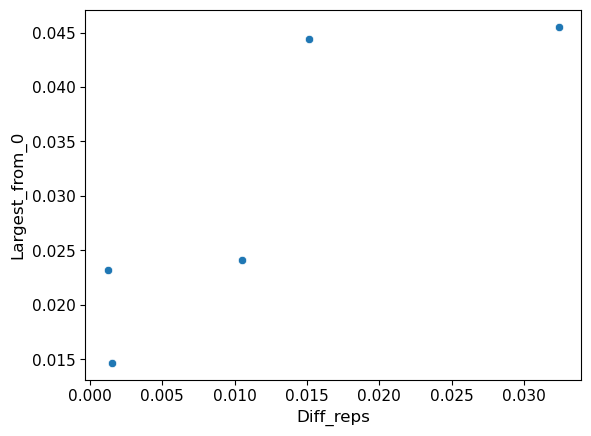

In [406]:
sns.scatterplot(data=diff_all_data, x='Diff_reps', y='Largest_from_0')

Does this mean something? Is it expected, or does it suggest that "significant" deviations from 0 can be explained by noise?

We can use random sampling to get a null expectation of the number of significant differences we should observe, using different thresholds.

Let's first assess whether the selection coefficients (all replicates from unbiased samples combined together) are normally distributed

<Axes: xlabel='s_T0toT2_Ref', ylabel='Count'>

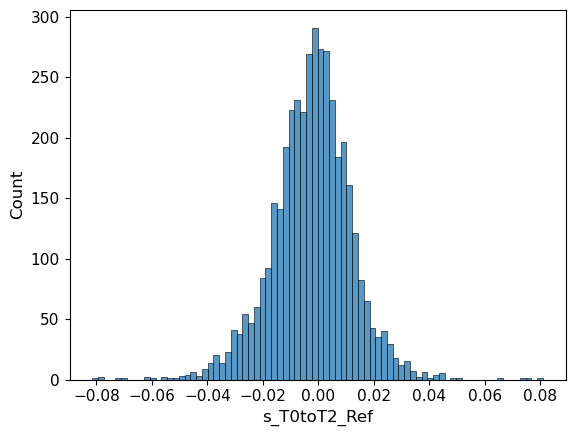

In [408]:
sns.histplot(s_F3F4['s_T0toT2_Ref'])

It looks like it! Let's still perform two statistical tests:

In [94]:
# We have more than 4000 datapoints, while the p-value "may not be accurate for > 5000".
# The test statistic suggests that a normal distribution is a perfectly fine approximation
stats.shapiro(s_F3F4['s_T0toT2_Ref'])

ShapiroResult(statistic=0.9814513880667913, pvalue=1.285447587885622e-22)

In [95]:
stats.jarque_bera(s_F3F4['s_T0toT2_Ref'])

SignificanceResult(statistic=798.3089696261275, pvalue=4.460769870770988e-174)

This second test, well suited for large samples, suggests that the distribution is not normal. Let's then simply try shuffling the data

<Axes: xlabel='count', ylabel='Count'>

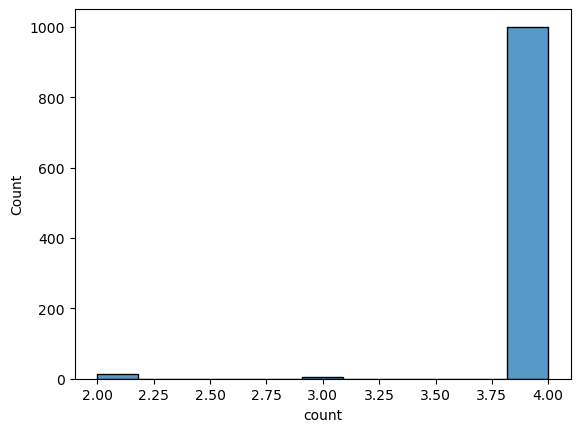

In [97]:
sns.histplot(s_F3F4['Genotype'].value_counts())

We have four replicates for almost all of the 1020 s measurements, so it's not worthwhile to vary the number of values which are sampled.

Seven significance thresholds are tested: 0.005, 0.01, 0.015, 0.02, 0.025, 0.04, 0.05. This is performed using both the boundaries of the replicate intervals and their medians

In [115]:
# Preparing a df to store the results
stat_thresh = [0.005, 0.01, 0.015, 0.02, 0.025, 0.04, 0.05]
shuffle_cols = ['n_iter'] + [f't_s_{s_val}' for s_val in stat_thresh] + [f'med_s_{s_val}' for s_val in stat_thresh]
s_shuffle_model = pd.DataFrame(columns=shuffle_cols)
#s_shuffle_df = s_shuffle_model.copy()

In [116]:
# Let's perform 10 000 iterations of the shuffling
n_iter = 10000
n_mutants = 1020
n_reps = 4

for iter_num in range(n_iter):

    # Sampling 1020 sets of four selection coefficients
    s_samp = rng_boot.choice(s_F3F4['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)

    # Making arrays of min and max values
    min_samp = np.min(s_samp, axis=0)
    max_samp = np.max(s_samp, axis=0)
    med_samp = np.median(s_samp, axis=0)

    # For each chosen significance threshold, the number of significant mutational effects is assessed
    current_df = s_shuffle_model.copy()
    current_df.at[0, 'n_iter'] = iter_num 
    for min_abs in stat_thresh:
        n_above = np.where(min_samp > min_abs, 1, 0).sum()
        n_below = np.where(max_samp < -min_abs, 1, 0).sum()
        n_total = n_above + n_below

        stat_col = f't_s_{min_abs}'
        current_df.at[0, stat_col] = n_total

        # Also for medians
        med_above = np.where(med_samp > min_abs, 1, 0).sum()
        med_below = np.where(med_samp < -min_abs, 1, 0).sum()
        med_total = med_above + med_below

        med_col = f'med_s_{min_abs}'
        current_df.at[0, med_col] = med_total

    # Adding data to the main df
    if iter_num == 0:
        s_shuffle_df = current_df.copy()

    else:
        s_shuffle_df = pd.concat([s_shuffle_df, current_df]).reset_index(drop=True)

In [117]:
# Computing medians and 95% confidence intervals
s_shuffle_df['Type'] = 'Median'
s_shuffle_med = s_shuffle_df.groupby(by='Type', as_index=False).median()

s_shuffle_df['Type'] = '97.5%'
s_shuffle_max = s_shuffle_df.infer_objects().groupby(by='Type', as_index=False).quantile(0.975)

s_shuffle_df['Type'] = '95%'
s_shuffle_95 = s_shuffle_df.infer_objects().groupby(by='Type', as_index=False).quantile(0.95)

s_shuffle_df['Type'] = '5%'
s_shuffle_5 = s_shuffle_df.infer_objects().groupby(by='Type', as_index=False).quantile(0.05)

s_shuffle_df['Type'] = '2.5%'
s_shuffle_min = s_shuffle_df.infer_objects().groupby(by='Type', as_index=False).quantile(0.025)

# Combining together
s_shuffle_summary = pd.concat([s_shuffle_min, s_shuffle_5, s_shuffle_med, s_shuffle_95, s_shuffle_max]).drop(columns='n_iter').reset_index(drop=True)

The same values are computed on the real data

In [119]:
s_sign_real = pd.DataFrame(columns=['Type'] + shuffle_cols)

for min_abs in stat_thresh:
    n_above = s_med_F3F4[s_med_F3F4['Min_s_ignored'] > min_abs].shape[0]
    n_below = s_med_F3F4[s_med_F3F4['Max_s_ignored'] < -min_abs].shape[0]
    n_total = n_above + n_below

    s_sign_real.at[0, f't_s_{min_abs}'] = n_total

    med_above = s_med_F3F4[s_med_F3F4['Median_s_ignored'] > min_abs].shape[0]
    med_below = s_med_F3F4[s_med_F3F4['Median_s_ignored'] < -min_abs].shape[0]
    med_total = med_above + med_below

    s_sign_real.at[0, f'med_s_{min_abs}'] = med_total

s_sign_real = s_sign_real.drop(columns='n_iter')
s_sign_real['Type'] = 'Data'

In [120]:
s_shuffle_comp = pd.concat([s_shuffle_summary, s_sign_real])
s_shuffle_comp

,Type,t_s_0.005,t_s_0.01,t_s_0.015,t_s_0.02,t_s_0.025,t_s_0.04,t_s_0.05,med_s_0.005,med_s_0.01,med_s_0.015,med_s_0.02,med_s_0.025,med_s_0.04,med_s_0.05
0,2.5%,22.0,1.0,0.0,0.0,0.0,0.0,0.0,460.0,150.0,36.0,6.0,0.0,0.0,0.0
1,5%,24.0,2.0,0.0,0.0,0.0,0.0,0.0,464.0,153.0,38.0,7.0,0.0,0.0,0.0
2,Median,33.0,5.0,1.0,0.0,0.0,0.0,0.0,490.0,173.0,49.0,12.0,2.0,0.0,0.0
3,95%,42.0,10.0,2.0,1.0,0.0,0.0,0.0,517.0,193.0,60.0,18.0,6.0,0.0,0.0
4,97.5%,44.0,10.0,3.0,1.0,0.0,0.0,0.0,522.0,197.0,63.0,19.0,6.0,0.0,0.0
0,Data,37,12,2,2,1,0,0,498,191,59,22,9,0,0


The number of "significant" fitness effects is much higher in the real data than in the shuffled dataset. This suggests that there could be some "real" fitness effects, although there are clearly very few ones which are strong enough to be measured confidently.

There is however a major issue with this approach: the replicate structure (two pairs of bio rep) has not been conserved.

Let's try repeating the same test, but by sampling two values from each pair of biological replicates (instead of four values from the complete set of measurements).

In [124]:
# Preparing a df to store the results
stat_thresh = [0.005, 0.01, 0.015, 0.02, 0.025, 0.04, 0.05]
shuffle_cols = ['n_iter'] + [f't_s_{s_val}' for s_val in stat_thresh] + [f'med_s_{s_val}' for s_val in stat_thresh]
s_shuffle_model = pd.DataFrame(columns=shuffle_cols)
#s_shuffle_df = s_shuffle_model.copy()

# Let's perform 10 000 iterations of the shuffling
n_iter = 10000
n_mutants = 1020
n_reps = 2

for iter_num in range(n_iter):

    # Sampling two times 1020 sets of two selection coefficients
    bio_a = s_F3F4[s_F3F4['Bio_rep'] == 2].copy().reset_index(drop=True)
    bio_b = s_F3F4[s_F3F4['Bio_rep'] == 4].copy().reset_index(drop=True)

    s_samp_a = rng_boot.choice(bio_a['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)
    s_samp_b = rng_boot.choice(bio_b['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)

    # Concatenating the two arrays
    s_samp_all = np.concatenate([s_samp_a, s_samp_b], axis=0)

    # Making arrays of min and max values
    min_samp = np.min(s_samp_all, axis=0)
    max_samp = np.max(s_samp_all, axis=0)
    med_samp = np.median(s_samp_all, axis=0)

    # For each chosen significance threshold, the number of significant mutational effects is assessed
    current_df = s_shuffle_model.copy()
    current_df.at[0, 'n_iter'] = iter_num 
    for min_abs in stat_thresh:
        n_above = np.where(min_samp > min_abs, 1, 0).sum()
        n_below = np.where(max_samp < -min_abs, 1, 0).sum()
        n_total = n_above + n_below

        stat_col = f't_s_{min_abs}'
        current_df.at[0, stat_col] = n_total

        # Also for medians
        med_above = np.where(med_samp > min_abs, 1, 0).sum()
        med_below = np.where(med_samp < -min_abs, 1, 0).sum()
        med_total = med_above + med_below

        med_col = f'med_s_{min_abs}'
        current_df.at[0, med_col] = med_total

    # Adding data to the main df
    if iter_num == 0:
        s_shuffle_bio = current_df.copy()

    else:
        s_shuffle_bio = pd.concat([s_shuffle_bio, current_df]).reset_index(drop=True)

In [125]:
# Computing medians and 95% confidence intervals
s_shuffle_bio['Type'] = 'Median'
s_bio_med = s_shuffle_bio.groupby(by='Type', as_index=False).median()

s_shuffle_bio['Type'] = '97.5%'
s_bio_max = s_shuffle_bio.infer_objects().groupby(by='Type', as_index=False).quantile(0.975)

s_shuffle_bio['Type'] = '95%'
s_bio_95 = s_shuffle_bio.infer_objects().groupby(by='Type', as_index=False).quantile(0.95)

s_shuffle_bio['Type'] = '5%'
s_bio_5 = s_shuffle_bio.infer_objects().groupby(by='Type', as_index=False).quantile(0.05)

s_shuffle_bio['Type'] = '2.5%'
s_bio_min = s_shuffle_bio.infer_objects().groupby(by='Type', as_index=False).quantile(0.025)

# Combining together
s_bio_summary = pd.concat([s_bio_min, s_bio_5, s_bio_med, s_bio_95, s_bio_max]).drop(columns='n_iter').reset_index(drop=True)

In [126]:
# Comparing with the real data
s_bio_comp = pd.concat([s_bio_summary, s_sign_real])
s_bio_comp

,Type,t_s_0.005,t_s_0.01,t_s_0.015,t_s_0.02,t_s_0.025,t_s_0.04,t_s_0.05,med_s_0.005,med_s_0.01,med_s_0.015,med_s_0.02,med_s_0.025,med_s_0.04,med_s_0.05
0,2.5%,22.0,1.0,0.0,0.0,0.0,0.0,0.0,457.0,149.0,36.0,6.0,0.0,0.0,0.0
1,5%,23.0,2.0,0.0,0.0,0.0,0.0,0.0,462.0,153.0,38.0,7.0,0.0,0.0,0.0
2,Median,32.0,5.0,1.0,0.0,0.0,0.0,0.0,489.0,172.0,48.0,12.0,2.0,0.0,0.0
3,95%,42.0,10.0,2.0,1.0,0.0,0.0,0.0,515.0,192.0,60.0,18.0,5.0,0.0,0.0
4,97.5%,44.0,11.0,3.0,1.0,0.0,0.0,0.0,521.0,197.0,62.0,19.0,6.0,0.0,0.0
0,Data,37,12,2,2,1,0,0,498,191,59,22,9,0,0


This does not change the conclusion that there appears to be some signal for (very weak) effects in the screen. What about sampling one value from each experiment?

In [316]:
# Preparing a df to store the results
stat_thresh = [0.005, 0.0075, 0.01, 0.0125, 0.015, 0.0175, 0.02, 0.025, 0.03]
shuffle_cols = ['n_iter'] + [f't_s_{s_val}' for s_val in stat_thresh] + [f'med_s_{s_val}' for s_val in stat_thresh]
s_shuffle_model = pd.DataFrame(columns=shuffle_cols)
#s_shuffle_df = s_shuffle_model.copy()

# Let's perform 10 000 iterations of the shuffling
n_iter = 10000
n_mutants = 1020
n_reps = 1

for iter_num in range(n_iter):

    # Sampling two times 1020 sets of two selection coefficients
    tech_1 = s_F3F4[s_F3F4['Alias'] == 14].copy().reset_index(drop=True)
    tech_2 = s_F3F4[s_F3F4['Alias'] == 15].copy().reset_index(drop=True)
    tech_3 = s_F3F4[s_F3F4['Alias'] == 18].copy().reset_index(drop=True)
    tech_4 = s_F3F4[s_F3F4['Alias'] == 19].copy().reset_index(drop=True)

    s_samp_1 = rng_boot.choice(tech_1['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)
    s_samp_2 = rng_boot.choice(tech_2['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)
    s_samp_3 = rng_boot.choice(tech_3['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)
    s_samp_4 = rng_boot.choice(tech_4['s_T0toT2_Ref'].values, size=(n_reps, n_mutants), replace=True)

    # Concatenating the two arrays
    s_samp_all = np.concatenate([s_samp_1, s_samp_2, s_samp_3, s_samp_4], axis=0)

    # Making arrays of min and max values
    min_samp = np.min(s_samp_all, axis=0)
    max_samp = np.max(s_samp_all, axis=0)
    med_samp = np.median(s_samp_all, axis=0)

    # For each chosen significance threshold, the number of significant mutational effects is assessed
    current_df = s_shuffle_model.copy()
    current_df.at[0, 'n_iter'] = iter_num 
    for min_abs in stat_thresh:
        n_above = np.where(min_samp > min_abs, 1, 0).sum()
        n_below = np.where(max_samp < -min_abs, 1, 0).sum()
        n_total = n_above + n_below

        stat_col = f't_s_{min_abs}'
        current_df.at[0, stat_col] = n_total

        # Also for medians
        med_above = np.where(med_samp > min_abs, 1, 0).sum()
        med_below = np.where(med_samp < -min_abs, 1, 0).sum()
        med_total = med_above + med_below

        med_col = f'med_s_{min_abs}'
        current_df.at[0, med_col] = med_total

    # Adding data to the main df
    if iter_num == 0:
        s_shuffle_tech = current_df.copy()

    else:
        s_shuffle_tech = pd.concat([s_shuffle_tech, current_df]).reset_index(drop=True)

In [320]:
# Computing medians and 95% confidence intervals
s_shuffle_tech['Type'] = 'Median'
s_tech_med = s_shuffle_tech.groupby(by='Type', as_index=False).median()

s_shuffle_tech['Type'] = '97.5%'
s_tech_max = s_shuffle_tech.infer_objects().groupby(by='Type', as_index=False).quantile(0.975)

s_shuffle_tech['Type'] = '95%'
s_tech_95 = s_shuffle_tech.infer_objects().groupby(by='Type', as_index=False).quantile(0.95)

s_shuffle_tech['Type'] = '5%'
s_tech_5 = s_shuffle_tech.infer_objects().groupby(by='Type', as_index=False).quantile(0.05)

s_shuffle_tech['Type'] = '2.5%'
s_tech_min = s_shuffle_tech.infer_objects().groupby(by='Type', as_index=False).quantile(0.025)

# Combining together
s_tech_summary = pd.concat([s_tech_min, s_tech_5, s_tech_med, s_tech_95, s_tech_max]).drop(columns='n_iter').reset_index(drop=True)

In [321]:
# Remaking "s_sign_real" with more thresholdss_sign_real = pd.DataFrame(columns=['Type'] + shuffle_cols)
for min_abs in stat_thresh:
    n_above = s_med_F3F4[s_med_F3F4['Min_s_ignored'] > min_abs].shape[0]
    n_below = s_med_F3F4[s_med_F3F4['Max_s_ignored'] < -min_abs].shape[0]
    n_total = n_above + n_below

    s_sign_real.at[0, f't_s_{min_abs}'] = n_total

    med_above = s_med_F3F4[s_med_F3F4['Median_s_ignored'] > min_abs].shape[0]
    med_below = s_med_F3F4[s_med_F3F4['Median_s_ignored'] < -min_abs].shape[0]
    med_total = med_above + med_below

    s_sign_real.at[0, f'med_s_{min_abs}'] = med_total

#s_sign_real = s_sign_real.drop(columns='n_iter')
s_sign_real['Type'] = 'Data'

In [347]:
# Comparing with the real data
s_tech_comp = pd.concat([s_tech_summary, s_sign_real])
s_tech_comp

,Type,t_s_0.005,t_s_0.0075,t_s_0.01,t_s_0.0125,t_s_0.015,t_s_0.0175,t_s_0.02,t_s_0.025,t_s_0.03,...,med_s_0.0175,med_s_0.02,med_s_0.025,med_s_0.03,t_s_0.04,t_s_0.05,med_s_0.04,med_s_0.05,t_s_0.075,med_s_0.075
0,2.5%,22.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,5%,23.0,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,7.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Median,32.0,15.0,5.0,2.0,1.0,0.0,0.0,0.0,0.0,...,24.0,12.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,95%,42.0,22.0,10.0,5.0,2.0,1.0,1.0,0.0,0.0,...,33.0,18.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,97.5%,44.0,23.0,10.0,5.0,3.0,2.0,1.0,0.0,0.0,...,35.0,19.0,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
0,Data,37,21.0,12,5.0,2,2.0,2,1,0.0,...,37.0,22,9,6.0,0,0,0,0,0.0,0.0


In [348]:
# This last set of results is exported for use in a supp figure 
s_tech_comp.to_csv("Supp_data/shuffle_s_eval.csv", index=False)

It is suprising that these different sampling strategies have no impact on the result...

## Exporting the data (paired-end 300 selection coefficients, with 5-FC)

In [137]:
# Median s for F3F4 mutations, with p-values (t-test to see if diff from 0)
s_med_F3F4.to_csv("Supp_data/median_s_F3F4.csv", index=False)

# Final data, per library (only 5-FC and no spike-ins)
s_no_out.to_csv("Supp_data/s_300_5FC_no_out.csv", index=False)

## Are selection coefficients obtained with spike-ins comparable?

In [139]:
# Taking only the data for F3F4 sequencing WITH spikes-ins and 5-FC
s_300_spikes = s_filter_300[(s_filter_300['Condition'] == 'WITH_5FC') & (s_filter_300['With_CDS_spikeins'] == True)].copy().reset_index(drop=True)

Computing medians and corresponding absolute deviations and MAD, for each genotype

In [141]:
# Computing the median s for each genotype
s_medians_spikes = s_300_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref',
                                 's_T0toT3_Ref']].copy().groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).median()

s_medians_spikes = s_medians_spikes.rename(columns={'s_T0toT2_Ref': 'Median_s_T0toT2'})

In [142]:
# Preparing the dataframe for the MAD
s_MAD_spikes = s_300_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Alias', 'Bio_rep', 'Tech_rep',
                             'To_ignore', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref', 's_T0toT3_Ref']].copy()

# Adding the medians
s_MAD_spikes = pd.merge(s_MAD_spikes, s_medians_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Median_s_T0toT2']],
                        on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='left')

# Computing the absolute deviation from the median, and then the MAD
s_MAD_spikes['Abs_med_s_T0toT2'] = np.abs(s_MAD_spikes['s_T0toT2_Ref'] - s_MAD_spikes['Median_s_T0toT2'])

s_MAD_calc = s_MAD_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Abs_med_s_T0toT2']].copy()
s_MAD_calc = s_MAD_calc.groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).median()
s_MAD_calc = s_MAD_calc.rename(columns={'Abs_med_s_T0toT2': 'MAD_s_T0toT2'})
s_MAD_spikes = pd.merge(s_MAD_spikes, s_MAD_calc, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='left')

# For each estimate, converting each abs deviation into a number of MADs
s_MAD_spikes['n_MAD'] = s_MAD_spikes['Abs_med_s_T0toT2'] / s_MAD_spikes['MAD_s_T0toT2']

Adding standard deviation for each genotype

In [144]:
# Adding the standard deviation to the df
s_std = s_300_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).std()
s_std = s_std.rename(columns={'s_T0toT2_Ref': 'Std_s'})

s_min = s_300_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).min()
s_min = s_min.rename(columns={'s_T0toT2_Ref': 'Min_s'})

s_max = s_300_spikes[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).max()
s_max = s_max.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_bypos_spikes = pd.merge(s_std, s_min, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')
s_bypos_spikes = pd.merge(s_bypos_spikes, s_max, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')

### Looking at the distributions

1) Standard deviation by genotype

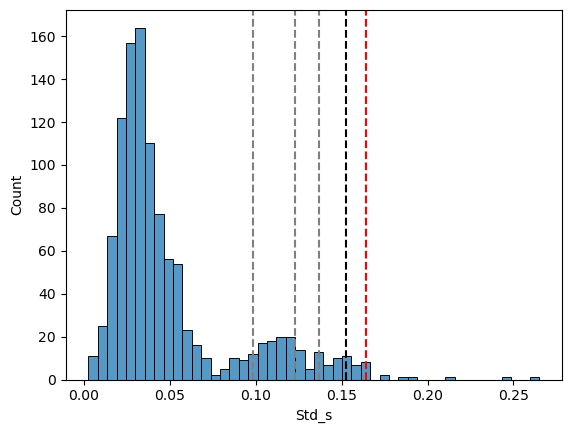

In [147]:
# Plotting the distribution of standard deviations, with 95th, 97.5th and 99th percentiles
std_85_sp = np.nanpercentile(s_bypos_spikes['Std_s'], 85)
std_925_sp = np.nanpercentile(s_bypos_spikes['Std_s'], 92.5)
std_95_sp = np.nanpercentile(s_bypos_spikes['Std_s'], 95)
std_975_sp = np.nanpercentile(s_bypos_spikes['Std_s'], 97.5)
std_99_sp = np.nanpercentile(s_bypos_spikes['Std_s'], 99)

sns.histplot(data=s_bypos_spikes, x='Std_s')
plt.axvline(x=std_85_sp, linestyle='--', c='grey')
plt.axvline(x=std_925_sp, linestyle='--', c='grey')
plt.axvline(x=std_95_sp, linestyle='--', c='grey')
plt.axvline(x=std_975_sp, linestyle='--', c='black')
plt.axvline(x=std_99_sp, linestyle='--', c='red')

We might need to be more stringent here and consider all genotypes above the 85th percentile as potential outliers, for the filtering to be comparable.

2. nMAD by s estimate

In [150]:
# Computing 95th, 97.5 and 99 percentiles
n_MAD_85_sp = np.nanpercentile(s_MAD_spikes['n_MAD'], 85)
n_MAD_95_sp = np.nanpercentile(s_MAD_spikes['n_MAD'], 95)
n_MAD_975_sp = np.nanpercentile(s_MAD_spikes['n_MAD'], 97.5)
n_MAD_99_sp = np.nanpercentile(s_MAD_spikes['n_MAD'], 99)

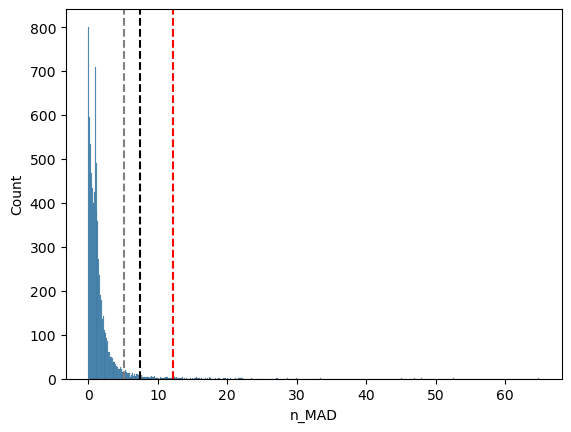

In [151]:
sns.histplot(data=s_MAD_spikes, x='n_MAD')
#plt.axvline(x=n_MAD_85_sp, linestyle='--', c='grey')
plt.axvline(x=n_MAD_95_sp, linestyle='--', c='grey')
plt.axvline(x=n_MAD_975_sp, linestyle='--', c='black')
plt.axvline(x=n_MAD_99_sp, linestyle='--', c='red')

There is no need to be more stringent in the filtering of estimates within each genotype. The 95th percentile will still be used as threshold.

### Filtering out outlier measurements

Within genotypes with standard deviation >= 85th percentile, datapoints with MAD >= 95th percentile are removed

In [155]:
# Selecting genotypes on which the filtering must be applied
out_df_spikes = s_bypos_spikes[s_bypos_spikes['Std_s'] >= std_85_sp].copy().reset_index(drop=True)
mut_to_filter_sp = out_df_spikes['Genotype'].unique()

In [156]:
# Identifying the datapoints to remove
not_filtered_sp =  s_MAD_spikes[~s_MAD_spikes['Genotype'].isin(mut_to_filter_sp)].copy()
to_filter_spikes = s_MAD_spikes[s_MAD_spikes['Genotype'].isin(mut_to_filter_sp)].copy()
to_filter_spikes['To_remove'] = to_filter_spikes['n_MAD'] > n_MAD_95_sp

Plotting the outliers to be filtered out

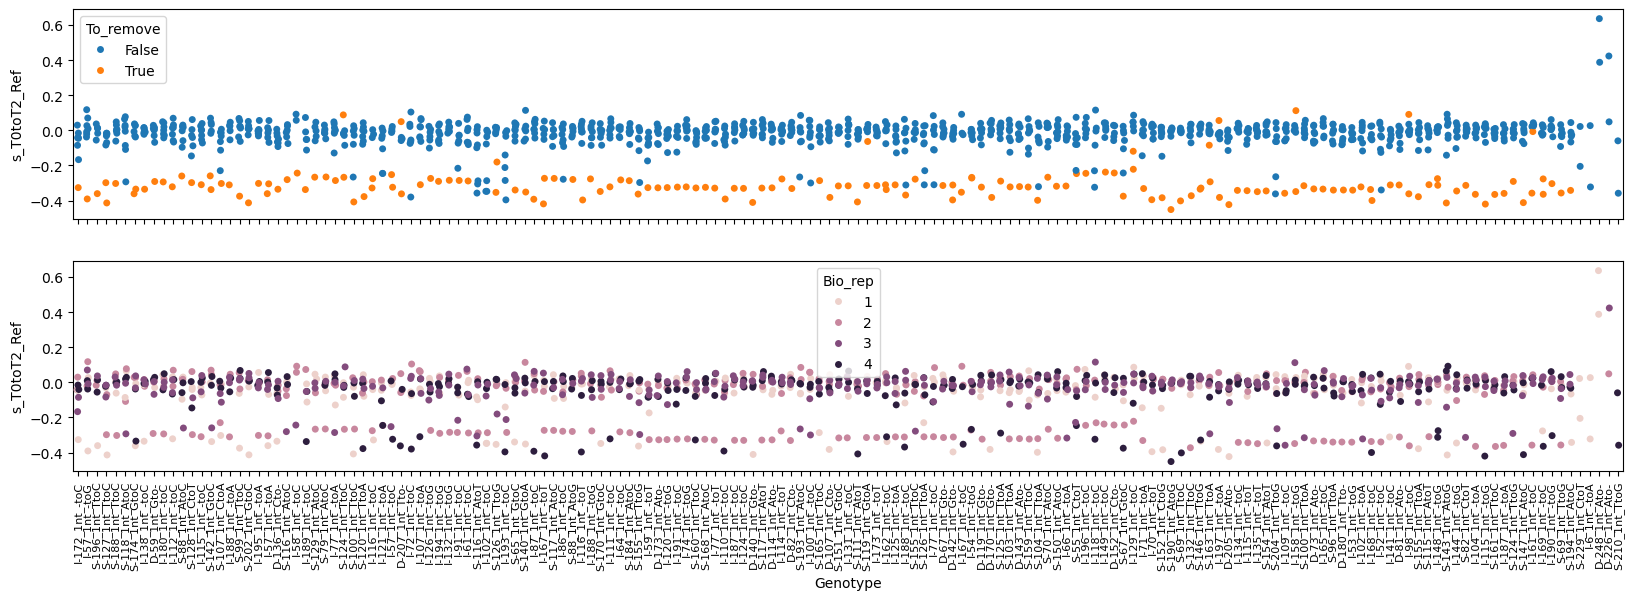

In [158]:
# All variants

fig, axs = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
sns.stripplot(data=to_filter_spikes, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_spikes, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

We are mostly removing spurious highly deleterious effects. There does not seem to be artifactually beneficial mutations in this dataset.

Culture replicates of the same transformation are not as ofter removed as a pair. Usually, only one measurement is an outlier.

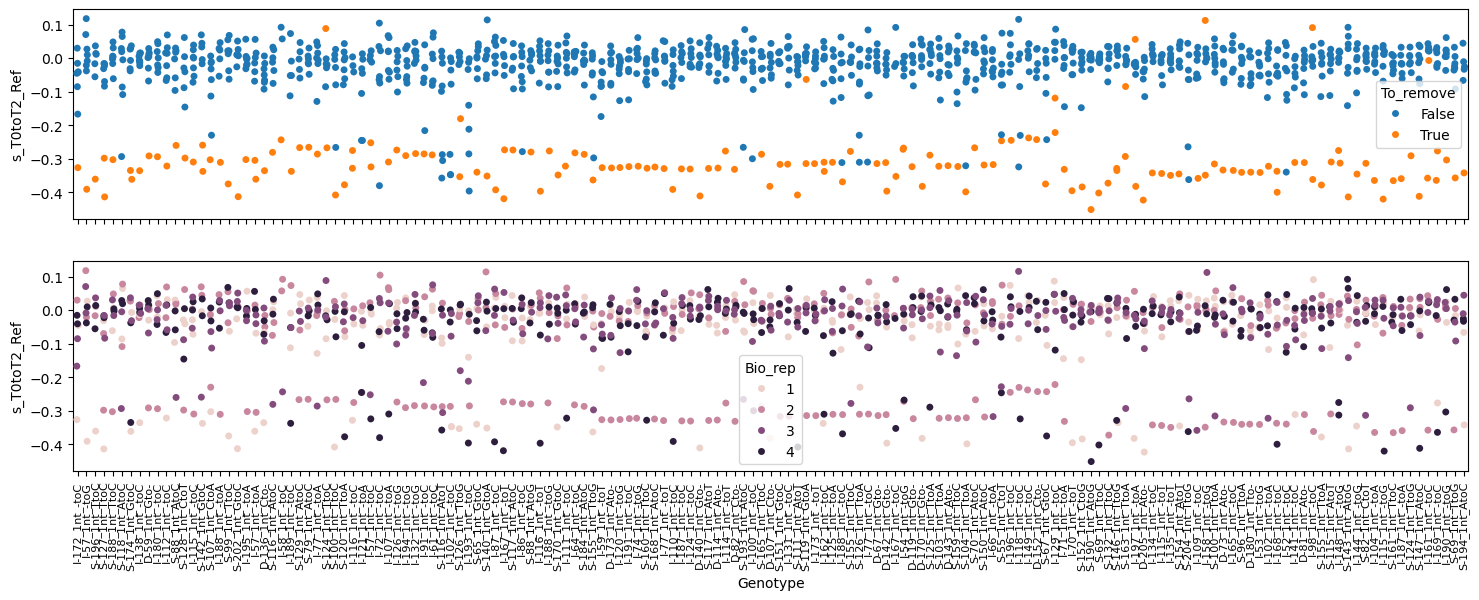

In [161]:
# Only mutations within the F3F4 region

to_filter_F3F4_sp = to_filter_spikes[to_filter_spikes['In F3F4'] == True].copy().reset_index(drop=True)

fig, axs = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
sns.stripplot(data=to_filter_F3F4_sp, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_F3F4_sp, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

Assembling the dataset without outliers

In [163]:
out_filtered_sp = to_filter_spikes[to_filter_spikes['To_remove'] == False].copy().reset_index(drop=True)
out_filtered_sp = out_filtered_sp.drop(columns=['To_remove'])
s_no_out_sp = pd.concat([not_filtered_sp, out_filtered_sp]).reset_index(drop=True)

### Comparing the estimated selection coefficients

#### Is the F3F4 data qualitatively similar?

Let's plot all non-outlier selection coefficients, as done previously

In [167]:
# Computing min and max s for each genotype
min_s_sp = s_no_out_sp[['Genotype', 's_T0toT2_Ref']].groupby(by='Genotype', as_index=False).min()
min_s_sp = min_s_sp.rename(columns={'s_T0toT2_Ref': 'Min_s'})
max_s_sp = s_no_out_sp[['Genotype', 's_T0toT2_Ref']].groupby(by='Genotype', as_index=False).max()
max_s_sp = max_s_sp.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_no_out_sp = pd.merge(s_no_out_sp, min_s_sp, on=['Genotype'], how='left')
s_no_out_sp = pd.merge(s_no_out_sp, max_s_sp, on=['Genotype'], how='left')

In [168]:
# Converting the mutation position and adding a column specifying the new base
s_no_out_sp['FCY1_position'] = s_no_out_sp['Position'] - 205 + 1*(s_no_out_sp['Mutation type'] == 'Insertion')
s_no_out_sp['New_nt'] = s_no_out_sp['Genotype'].apply(lambda x: x.split('to')[1])

In [169]:
# Version of the df without duplicates
s_medians_sp = s_no_out_sp.drop(columns=['Alias', 'Bio_rep', 'Tech_rep', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref',
                                         's_T0toT3_Ref', 'Abs_med_s_T0toT2', 'MAD_s_T0toT2', 'n_MAD']).copy()
s_medians_sp = s_medians_sp.drop_duplicates().reset_index(drop=True)

In [170]:
# Individually plotting all the selection coefficients
s_F3F4_sp = s_no_out_sp[s_no_out_sp['In F3F4'] == True].copy().reset_index(drop=True)

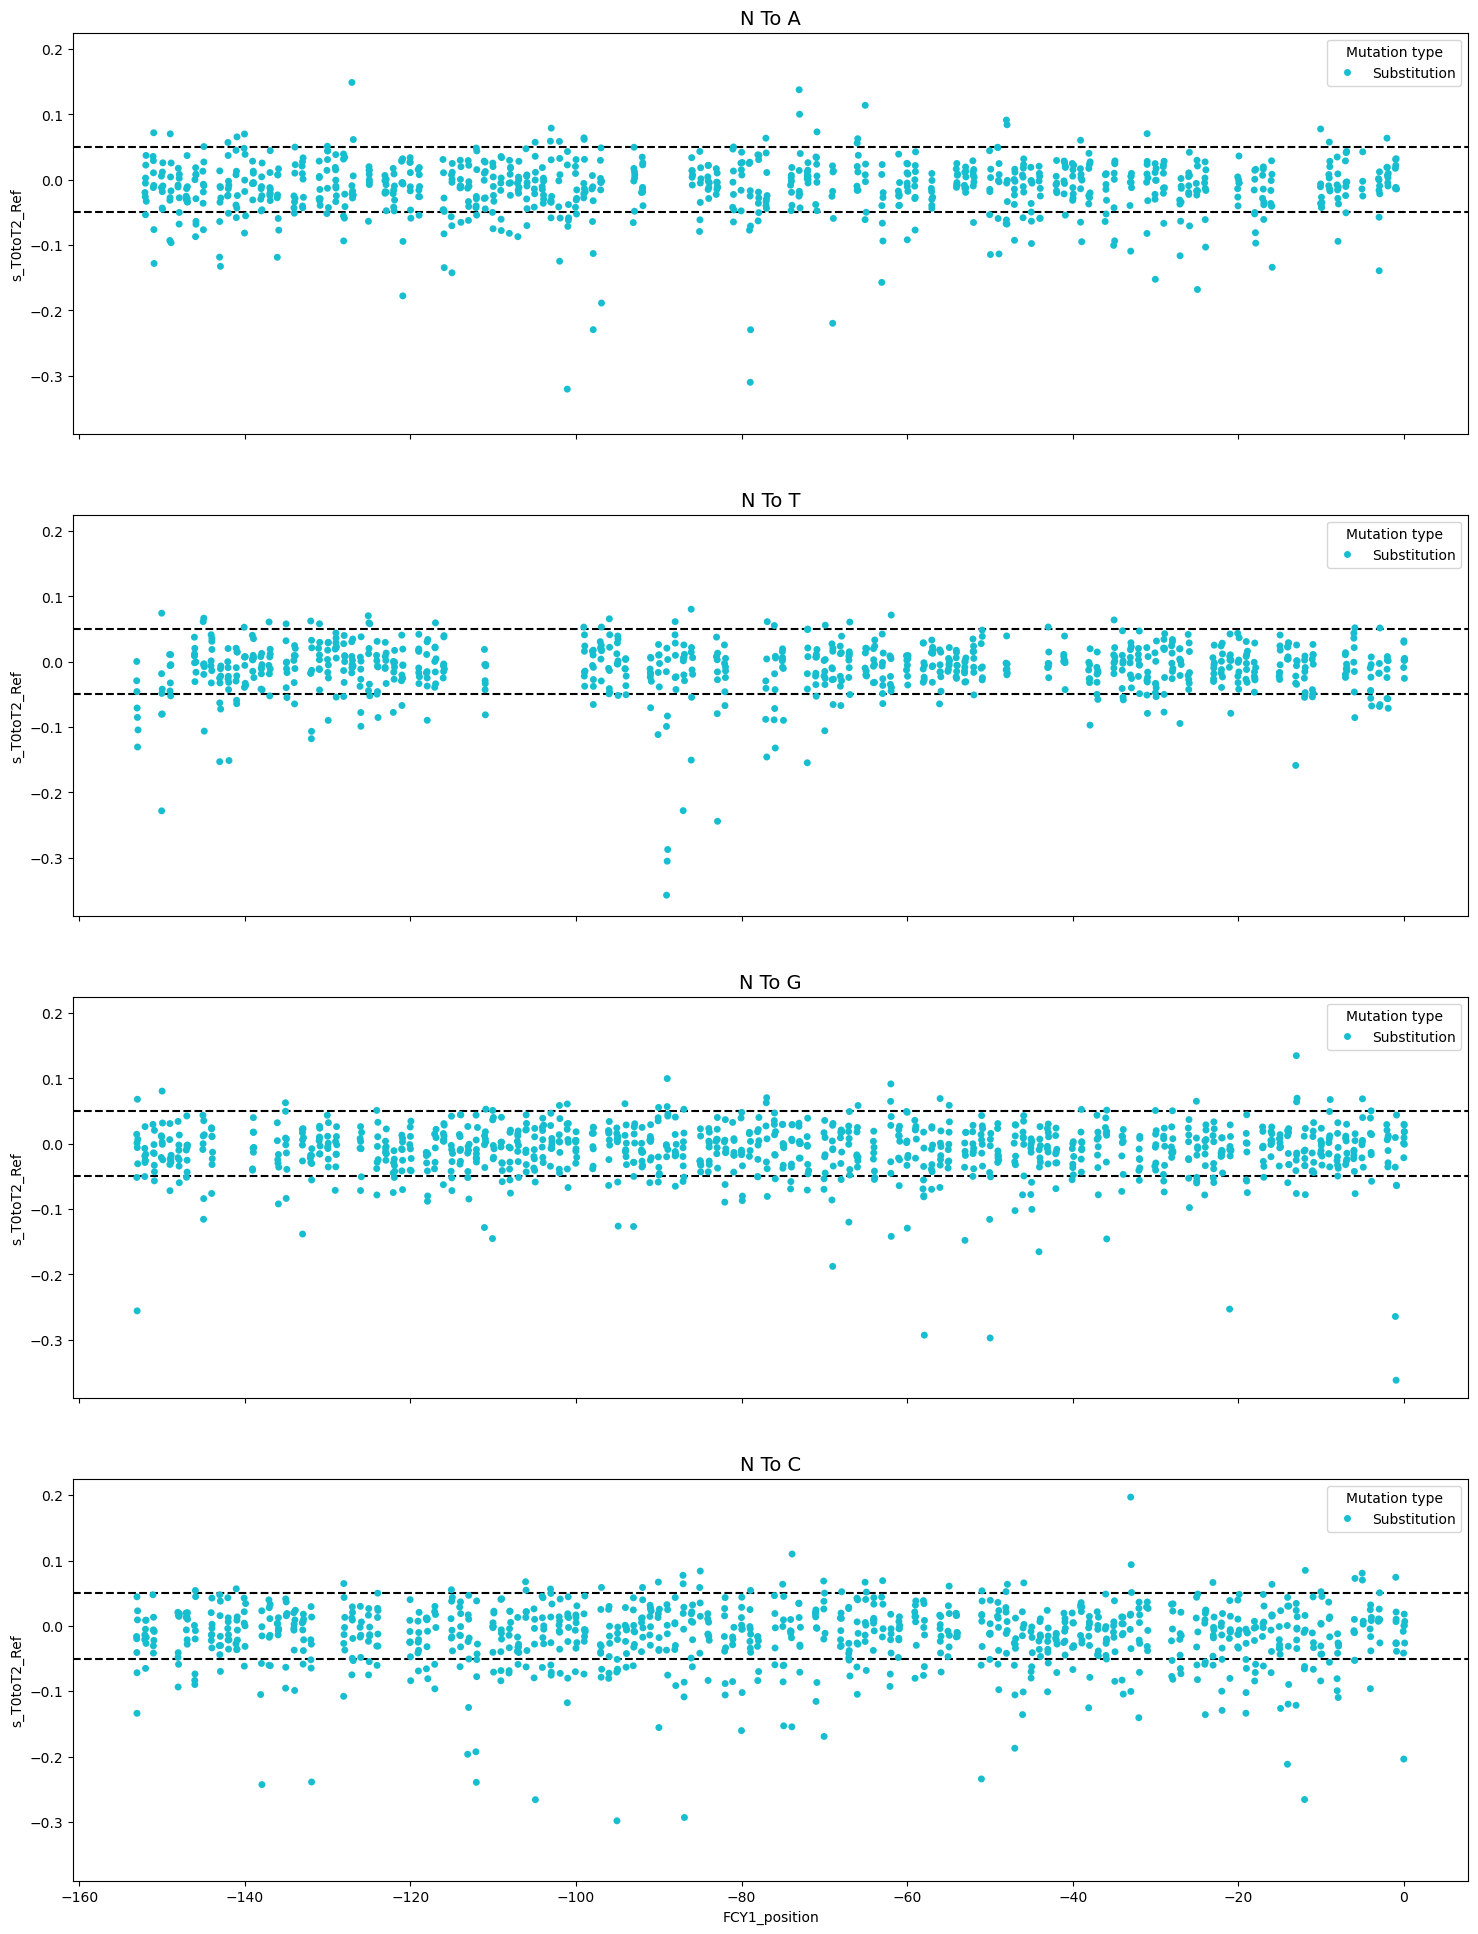

In [171]:
# First figure: Substitutions
# from top to bottom: A, T, G, C

s_F3F4_sub = s_F3F4_sp[s_F3F4_sp['Mutation type'] == 'Substitution'].copy().reset_index(drop=True)

fig, axs = plt.subplots(4, 1, figsize=(18, 24), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'A'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[0], palette=mut_palette, native_scale=True)
axs[0].set_title('N To A', fontsize=14)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'T'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[1], palette=mut_palette, native_scale=True)
axs[1].set_title('N To T', fontsize=14)


sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'G'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[2], palette=mut_palette, native_scale=True)
axs[2].set_title('N To G', fontsize=14)

sns.stripplot(data=s_F3F4_sub[s_F3F4_sub['New_nt'] == 'C'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[3], palette=mut_palette, native_scale=True)
axs[3].set_title('N To C', fontsize=14)

for k in range(4):
    axs[k].axhline(y=0.05, linestyle='--', c='black')
    axs[k].axhline(y=-0.05, linestyle='--', c='black')

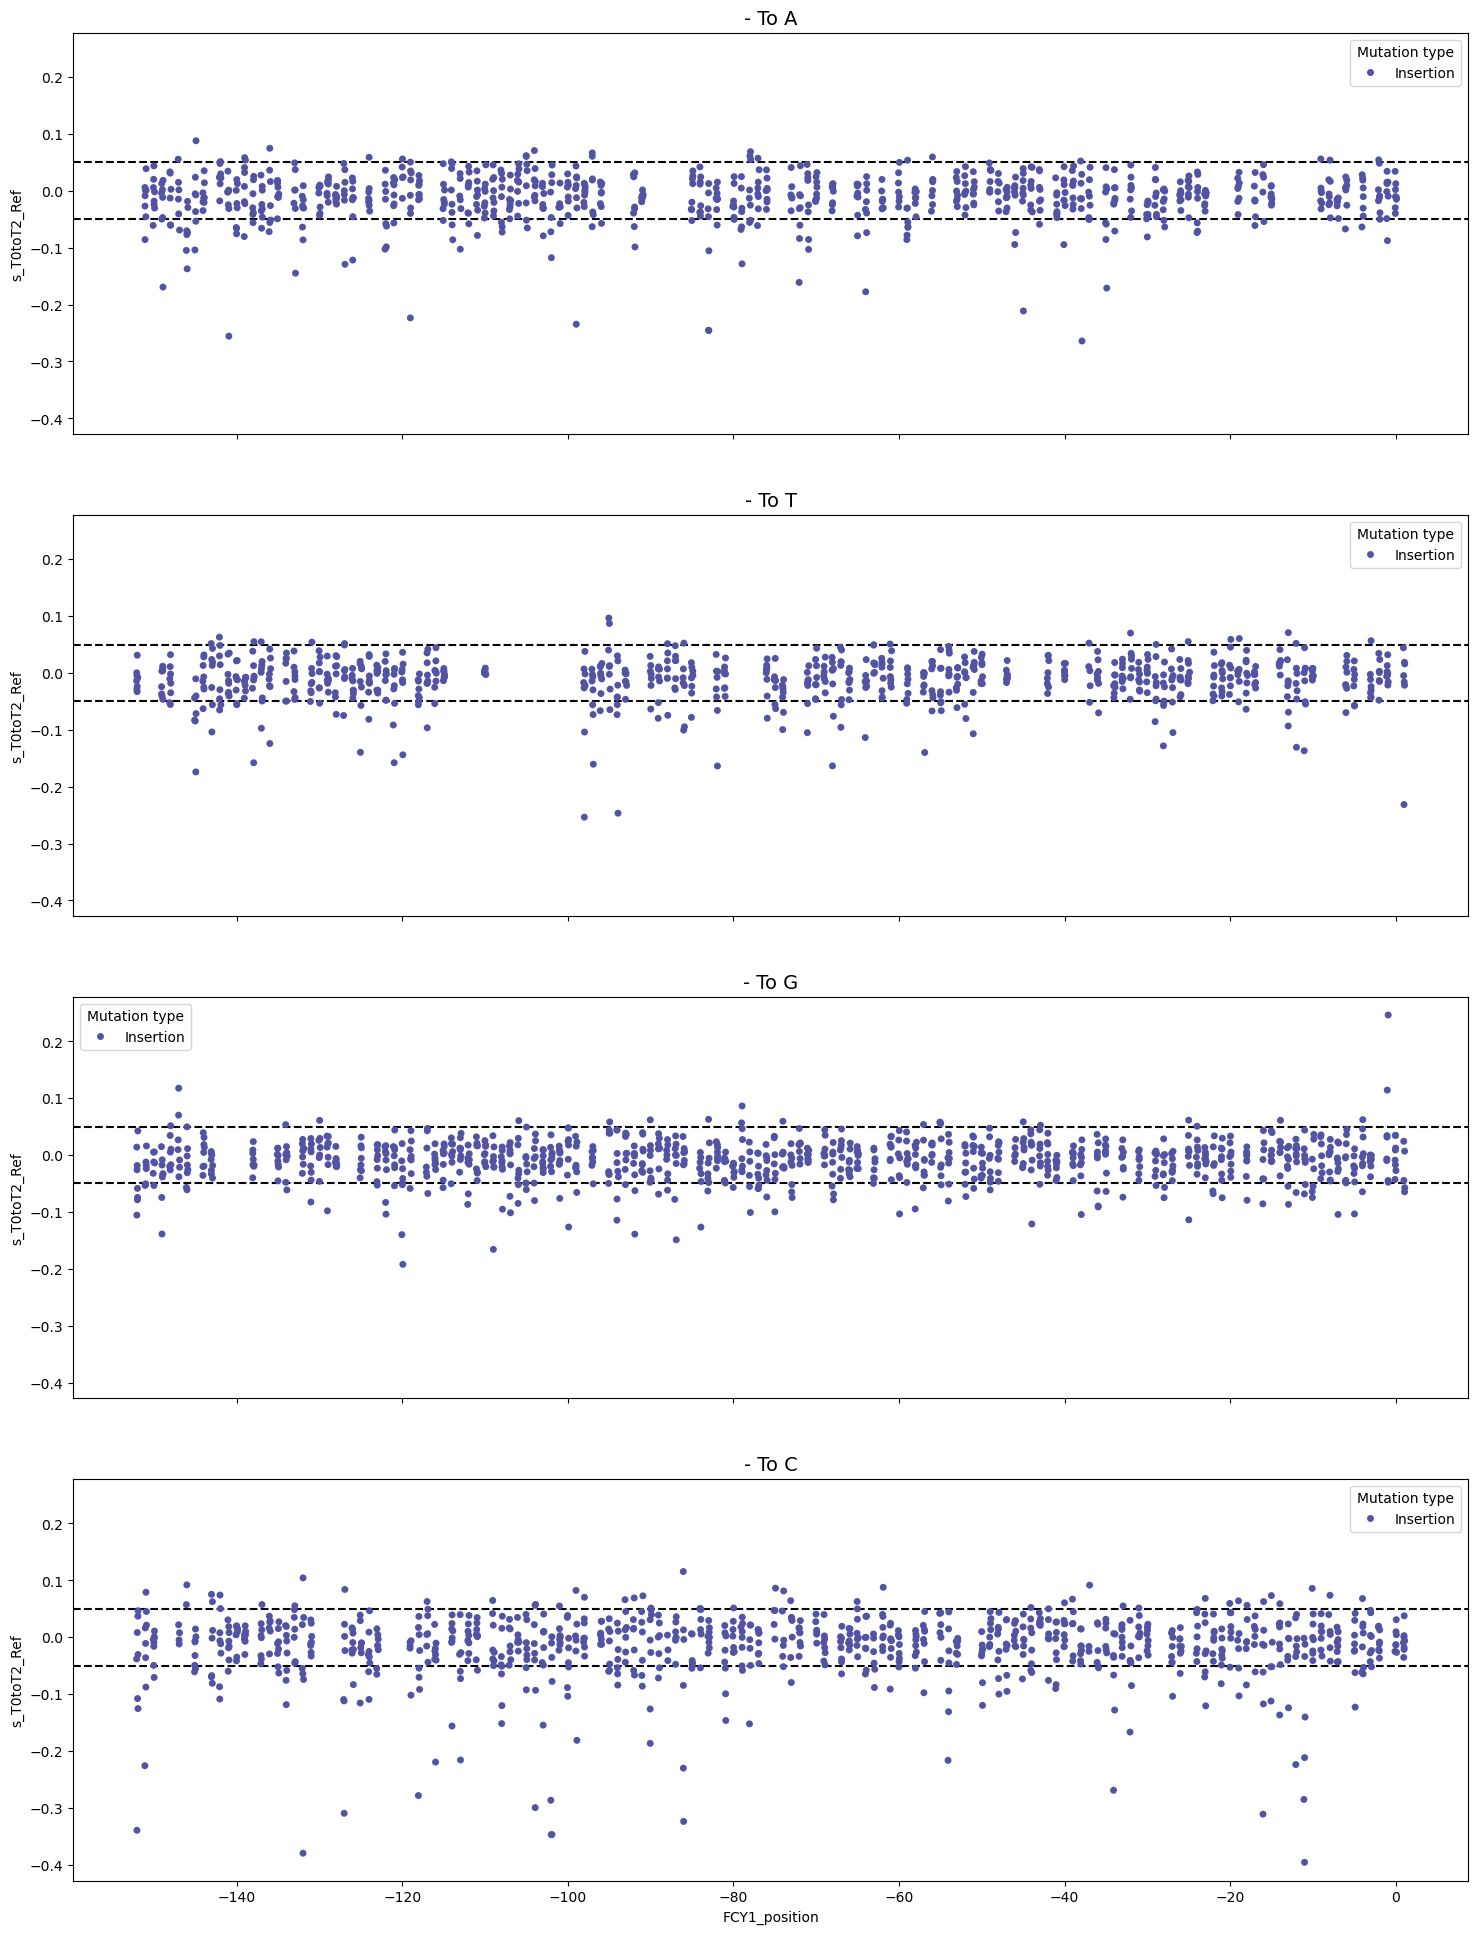

In [172]:
# Second figure: Insertions
# from top to bottom: A, T, G, C

s_F3F4_ins = s_F3F4_sp[s_F3F4_sp['Mutation type'] == 'Insertion'].copy().reset_index(drop=True)

fig, axs = plt.subplots(4, 1, figsize=(18, 24), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'A'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[0], palette=mut_palette, native_scale=True)
axs[0].set_title('- To A', fontsize=14)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'T'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[1], palette=mut_palette, native_scale=True)
axs[1].set_title('- To T', fontsize=14)


sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'G'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[2], palette=mut_palette, native_scale=True)
axs[2].set_title('- To G', fontsize=14)

sns.stripplot(data=s_F3F4_ins[s_F3F4_ins['New_nt'] == 'C'].copy(), x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=axs[3], palette=mut_palette, native_scale=True)
axs[3].set_title('- To C', fontsize=14)

for k in range(4):
    axs[k].axhline(y=0.05, linestyle='--', c='black')
    axs[k].axhline(y=-0.05, linestyle='--', c='black')

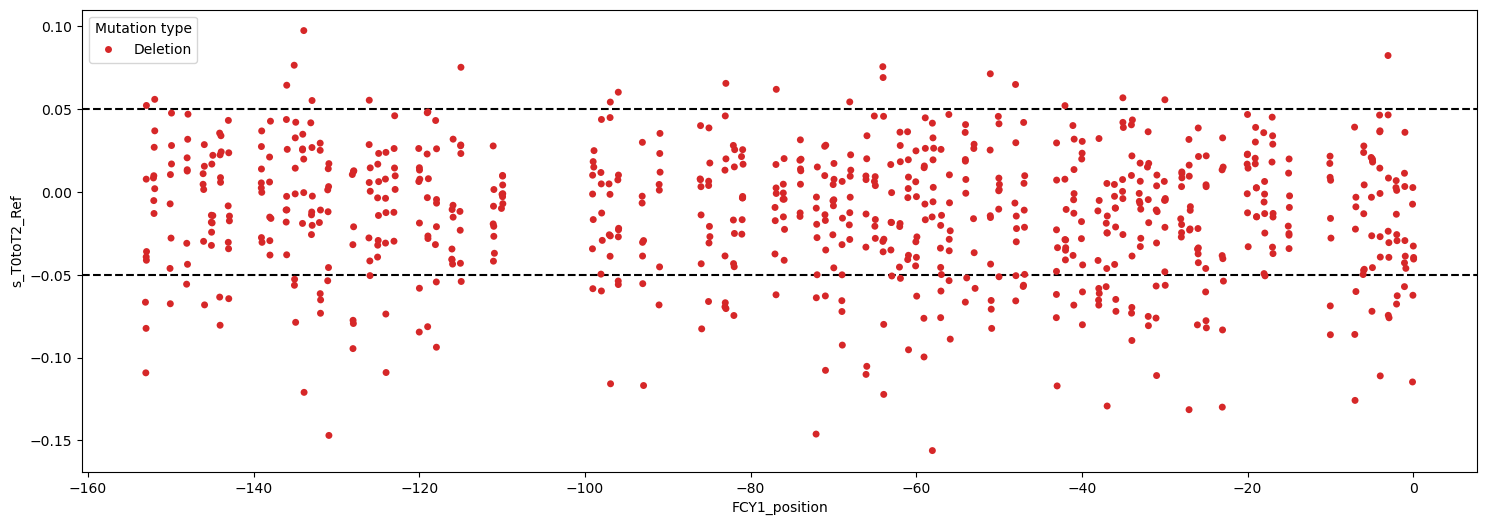

In [173]:
# Third figure: Deletions
# from top to bottom: A, T, G, C

s_F3F4_del = s_F3F4_sp[s_F3F4_sp['Mutation type'] == 'Deletion'].copy().reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(18, 6), sharex=True, sharey=True)

sns.stripplot(data=s_F3F4_del, x='FCY1_position', y='s_T0toT2_Ref',
             hue='Mutation type', ax=ax, palette=mut_palette, native_scale=True)

ax.axhline(y=0.05, linestyle='--', c='black')
ax.axhline(y=-0.05, linestyle='--', c='black')

There is more variance and many outliers (both negative and positive) remain, but the data is qualitatively similar!

#### How are selection coefficients from the two types of samples correlated?

Using the medians (**calculated before the removal of outliers**)

In [177]:
# Merging the data
medians_merged = pd.merge(s_medians, s_medians_sp, on=['Genotype', 'Position', 'In F3F4', 'Mutation type',
                                                      'FCY1_position', 'New_nt'], how='outer', suffixes=('', '_Spikes'))

Text(0.5, 1.0, 'Only F3-F4 variants')

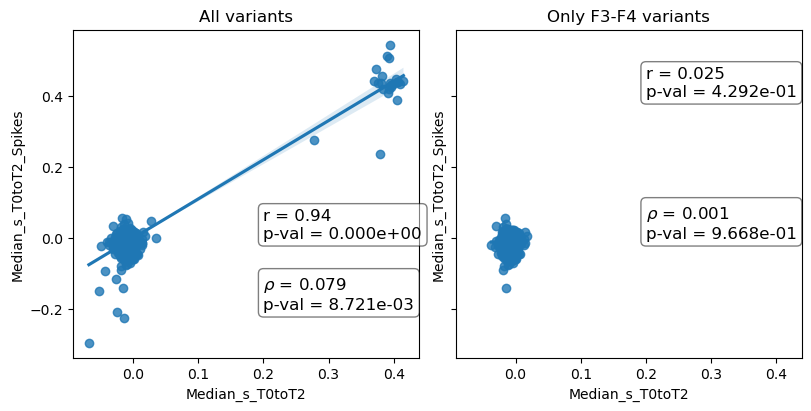

In [178]:
# For the OLS selection coefficients
fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True,
                       sharex=True, sharey=True)
# Left panel: All variants
all_sub = medians_merged.copy().dropna(subset=['Median_s_T0toT2', 'Median_s_T0toT2_Spikes']).reset_index(drop=True)

sns.regplot(data=all_sub, x='Median_s_T0toT2', y='Median_s_T0toT2_Spikes', ax=axs[0])

pearson_coeff = stats.pearsonr(all_sub['Median_s_T0toT2'], all_sub['Median_s_T0toT2_Spikes'])

axs[0].annotate(r"r = "f'{round(pearson_coeff[0], 3)}\np-val = {pearson_coeff[1]:.3e}',
                     (0.2, 0), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
    
spearman_coeff = stats.spearmanr(all_sub['Median_s_T0toT2'], all_sub['Median_s_T0toT2_Spikes'])
axs[0].annotate(r"$\rho$ = "f'{round(spearman_coeff[0], 3)}\np-val = {spearman_coeff[1]:.3e}',
                     (0.2, -0.2), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
axs[0].set_title('All variants')

# Right panel: Only F3F4
F3F4_sub = medians_merged[medians_merged['In F3F4'] == True].copy().dropna(subset=['Median_s_T0toT2', 'Median_s_T0toT2_Spikes']).reset_index(drop=True)

sns.regplot(data=F3F4_sub, x='Median_s_T0toT2', y='Median_s_T0toT2_Spikes', ax=axs[1])

pearson_coeff = stats.pearsonr(F3F4_sub['Median_s_T0toT2'], F3F4_sub['Median_s_T0toT2_Spikes'])

axs[1].annotate(r"r = "f'{round(pearson_coeff[0], 3)}\np-val = {pearson_coeff[1]:.3e}',
                     (0.2, 0.4), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
    
spearman_coeff = stats.spearmanr(F3F4_sub['Median_s_T0toT2'], F3F4_sub['Median_s_T0toT2_Spikes'])
axs[1].annotate(r"$\rho$ = "f'{round(spearman_coeff[0], 3)}\np-val = {spearman_coeff[1]:.3e}',
                     (0.2, 0), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
axs[1].set_title('Only F3-F4 variants')

The two series of samples agree very well for the variants which have fitness effects! Of course, there is no correlation among the F3-F4 variants, where no measurable fitness differences are detected.

In [360]:
np.median(s_medians[s_medians['Median_s_T0toT2'] > 0.2]['Median_s_T0toT2'])

0.3920841558428987

### Testing if there are measurable effects for F3F4 variants with spike-ins

In [181]:
s_med_sp_F3F4 = s_medians_sp[s_medians_sp['In F3F4'] == True].copy().reset_index(drop=True)

s_med_sp_F3F4['not_zero_p-val'] = np.nan
s_med_sp_F3F4['n_observed'] = np.nan

for row in range(s_med_sp_F3F4.shape[0]):
    current_mut = s_med_sp_F3F4.at[row, 'Genotype']
    data_subset = s_F3F4_sp[s_F3F4_sp['Genotype'] == current_mut].copy().reset_index(drop=True)
    n_obs = data_subset.shape[0]
    s_med_sp_F3F4.at[row, 'n_observed'] = n_obs
    t_test = stats.ttest_1samp(data_subset['s_T0toT2_Ref'], 0, nan_policy='omit')
    s_med_sp_F3F4.at[row, 'not_zero_p-val'] = t_test.pvalue

In [182]:
s_med_sp_F3F4.sort_values(by=['not_zero_p-val'])

,Genotype,Position,In F3F4,Mutation type,To_ignore,Median_s_T0toT2,Min_s,Max_s,FCY1_position,New_nt,not_zero_p-val,n_observed
968,I-161_1nt_-toC,161,True,Insertion,False,0.023635,0.020640,0.042977,-43,C,0.000393,6.0
541,S-83_1nt_CtoG,83,True,Substitution,False,-0.037684,-0.074655,-0.010576,-122,G,0.000800,8.0
350,I-174_1nt_-toA,174,True,Insertion,False,-0.041360,-0.080976,-0.017909,-30,A,0.000880,8.0
744,I-124_1nt_-toG,124,True,Insertion,False,-0.024187,-0.056979,-0.014332,-80,G,0.000883,8.0
45,S-73_1nt_AtoG,73,True,Substitution,False,-0.020018,-0.055375,-0.007503,-132,G,0.001812,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
828,S-185_1nt_GtoC,185,True,Substitution,False,-0.009594,-0.034075,0.048251,-20,C,0.996133,8.0
426,I-65_1nt_-toC,65,True,Insertion,False,0.003214,-0.030517,0.019895,-139,C,0.998148,8.0
196,S-65_1nt_GtoA,65,True,Substitution,False,-0.000810,-0.081786,0.069842,-140,A,0.998435,7.0
546,S-173_1nt_AtoT,173,True,Substitution,False,-0.000952,-0.048930,0.046967,-32,T,0.998788,8.0


In [183]:
s_med_sp_F3F4[(s_med_sp_F3F4['not_zero_p-val'] < 0.05) & (s_med_sp_F3F4['Median_s_T0toT2'] > 0)]

,Genotype,Position,In F3F4,Mutation type,To_ignore,Median_s_T0toT2,Min_s,Max_s,FCY1_position,New_nt,not_zero_p-val,n_observed
167,I-62_1nt_-toA,62,True,Insertion,False,0.023788,-0.017613,0.051554,-142,A,0.015120,8.0
186,I-155_1nt_-toA,155,True,Insertion,False,0.026247,-0.002383,0.049140,-49,A,0.019442,8.0
239,I-190_1nt_-toT,190,True,Insertion,False,0.017114,-0.003704,0.041089,-14,T,0.013868,7.0
416,I-141_1nt_-toT,141,True,Insertion,False,0.016394,-0.000602,0.049612,-63,T,0.019215,8.0
608,S-191_1nt_AtoT,191,True,Substitution,False,0.015017,0.003935,0.029004,-14,T,0.006335,8.0
968,I-161_1nt_-toC,161,True,Insertion,False,0.023635,0.020640,0.042977,-43,C,0.000393,6.0


In [184]:
s_med_sp_F3F4[s_med_sp_F3F4['not_zero_p-val'] < 0.05].shape[0]

75

There are 75 hits which are significantly different from 0 when using the F3F4 data from cultures with spike-ins, but they do not seem to make much sense (compared with the expression data from sort-seq). This is especially true since most of those "hits" are deleterious, while such fitness changes may not even be possible according to the fitness function we measured.

### Exporting the selection coefficients for samples with spike-ins

In [187]:
# Median s for F3F4 mutations, with p-values (t-test to see if diff from 0)
s_medians_sp.to_csv("Supp_data/median_s_F3F4_WithSpikes.csv", index=False)

# Final data, per library (only 5-FC and no spike-ins)
s_no_out_sp.to_csv("Supp_data/s_300_5FC_no_out_WithSpikes.csv", index=False)

## Is there a difference between samples with and without 5-FC?

This is assessed only for the cultures **without spike-ins**. In addition, the outlier removal steps are not performed for the samples without 5-FC. 

In [190]:
s_no_5FC = s_filter_300[(s_filter_300['Condition'] == 'NO_5FC') & (s_filter_300['With_CDS_spikeins'] == False)].copy().reset_index(drop=True)

In [191]:
# Keeping only the relevant columns and computing median as well as min and max selection coefficients
s_calc_no5FC = s_no_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 's_T0toT2_Ref']].copy()
s_med_no5FC = s_calc_no5FC.groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).median()
s_med_no5FC = s_med_no5FC.rename(columns={'s_T0toT2_Ref': 'Median_s_T0toT2'})

s_min_no5FC = s_calc_no5FC.groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).min()
s_min_no5FC = s_min_no5FC.rename(columns={'s_T0toT2_Ref': 'Min_s'})

s_max_no5FC = s_calc_no5FC.groupby(by=['Genotype', 'Position', 'In F3F4', 'Mutation type'], as_index=False).max()
s_max_no5FC = s_max_no5FC.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_med_no5FC = pd.merge(s_med_no5FC, s_min_no5FC, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')
s_med_no5FC = pd.merge(s_med_no5FC, s_max_no5FC, on=['Genotype', 'Position', 'In F3F4', 'Mutation type'], how='outer')

# Adding FCY1 position and new_nt
s_med_no5FC['FCY1_position'] = s_med_no5FC['Position'] - 205 + 1*(s_med_no5FC['Mutation type'] == 'Insertion')
s_med_no5FC['New_nt'] = s_med_no5FC['Genotype'].apply(lambda x: x.split('to')[1])

In [192]:
# Concatenating the data
s_med_no5FC['Condition'] = 'No 5-FC'
s_medians['Condition'] = 'With 5-FC'

s_comp = pd.concat([s_medians, s_med_no5FC]).reset_index(drop=True)

Text(0.5, 1.0, 'Only F3-F4 variants')

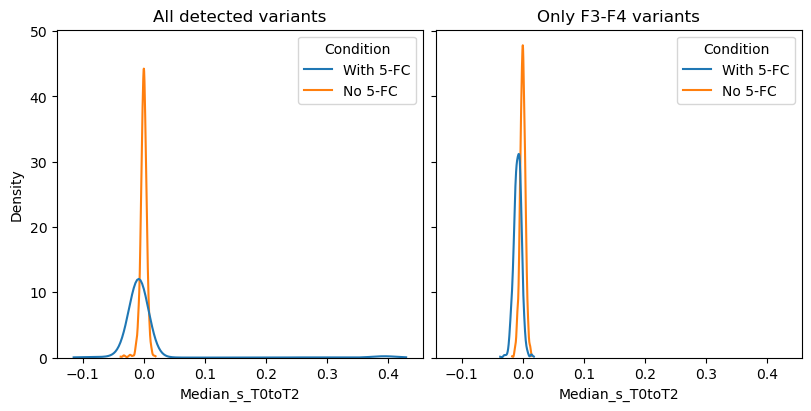

In [193]:
# Plotting the two distributions (of medians)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True,
                       sharex=True, sharey=True)

# Left: All variants
sns.kdeplot(data=s_comp, x='Median_s_T0toT2', hue='Condition', ax=axs[0], cut=0)
axs[0].set_title('All detected variants')

# Right: Only F3F4 variants
s_comp_F3F4 = s_comp[s_comp['In F3F4'] == True].copy().reset_index(drop=True)
sns.kdeplot(data=s_comp_F3F4, x='Median_s_T0toT2', hue='Condition', ax=axs[1], cut=0)
axs[1].set_title('Only F3-F4 variants')

In [194]:
# What is the standard deviation of the "no 5-FC" distribution?
np.std(s_med_no5FC[s_med_no5FC['In F3F4'] == True].copy()['Median_s_T0toT2'])

0.00439898135424531

In [195]:
s_med_no5FC

,Genotype,Position,In F3F4,Mutation type,Median_s_T0toT2,Min_s,Max_s,FCY1_position,New_nt,Condition
0,D-106_1nt_Gto-,106,True,Deletion,-0.002743,-0.012439,0.013622,-99,-,No 5-FC
1,D-107_1nt_Cto-,107,True,Deletion,0.003616,-0.004197,0.008741,-98,-,No 5-FC
2,D-108_1nt_Gto-,108,True,Deletion,0.002286,-0.010949,0.006855,-97,-,No 5-FC
3,D-109_1nt_Ato-,109,True,Deletion,-0.001729,-0.005641,0.005058,-96,-,No 5-FC
4,D-112_1nt_Tto-,112,True,Deletion,0.002338,-0.008813,0.009687,-93,-,No 5-FC
...,...,...,...,...,...,...,...,...,...,...
1082,S-98_1nt_TtoC,98,True,Substitution,0.005910,-0.005168,0.009294,-107,C,No 5-FC
1083,S-98_1nt_TtoG,98,True,Substitution,-0.001926,-0.005423,0.008295,-107,G,No 5-FC
1084,S-99_1nt_TtoA,99,True,Substitution,-0.001115,-0.012781,0.005527,-106,A,No 5-FC
1085,S-99_1nt_TtoC,99,True,Substitution,-0.001209,-0.006987,0.004908,-106,C,No 5-FC


Testing if the two distributions are significantly different

In [197]:
# All variants
stats.ks_2samp(s_medians['Median_s_T0toT2'], s_med_no5FC['Median_s_T0toT2'])

KstestResult(statistic=0.5642343100602217, pvalue=4.9179476003300617e-163, statistic_location=-0.00426923779617055, statistic_sign=1)

In [198]:
# F3F4 variants
stats.ks_2samp(s_medians[s_medians['In F3F4'] == True]['Median_s_T0toT2'], s_med_no5FC[s_med_no5FC['In F3F4'] == True]['Median_s_T0toT2'])

KstestResult(statistic=0.5980392156862745, pvalue=6.827770051990793e-170, statistic_location=-0.00426923779617055, statistic_sign=1)

In both cases, the distributions are significantly different! How can that be the case for the F3-F4 variants, if there are no measurable fitness effects? 

We see that the 5-FC distribution (for F3-F4 variants) is mostly shifted to the left. This could be explained by some rare beneficial secondary mutations going undetected and inflating the apparent fitness of the WT.

# For the CDS spike-ins libraries (only sequenced in 150 paired-end)

## Importing the final **filtered** selection coefficients:

In [203]:
s_filter_CDS = pd.read_csv("s_final/s_150_CDS_filtered.csv")
to_drop = ['s_T0toT1_Total', 's_T0toT2_Total', 's_T0toT3_Total', 'intercept_T0toT1_Total', 
           'intercept_T0toT2_Total', 'intercept_T0toT3_Total', 'ratio_T0toT1_Total',
           'ratio_T0toT2_Total', 'ratio_T0toT3_Total', 'intercept_T0toT3_Ref',
           'ratio_T0toT3_Ref', 's_T0toT1_Time', 's_T0toT2_Time', 's_T0toT3_Time', 
           'intercept_T0toT1_Time', 'intercept_T0toT2_Time', 'intercept_T0toT3_Time',
           'ratio_T0toT1_Time','ratio_T0toT2_Time','ratio_T0toT3_Time']
s_filter_CDS = s_filter_CDS.drop(columns=to_drop)

In [204]:
# Selecting only the data with 5-FC
s_CDS_5FC = s_filter_CDS[s_filter_CDS['Condition'] == 'WITH_5FC'].copy().reset_index(drop=True)

## Filtering potential outliers

### Computing medians, MADs and standard deviations

In [207]:
# Computing the median s for each genotype
s_medians_CDS = s_CDS_5FC[['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types',
                           'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref',
                           's_T0toT3_Ref']].copy().groupby(by=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], as_index=False).median()

s_medians_CDS = s_medians_CDS.rename(columns={'s_T0toT2_Ref': 'Median_s_T0toT2'})

In [208]:
# Preparing the dataframe for the MAD
s_MAD_CDS = s_CDS_5FC[['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types',
                       'Alias', 'Bio_rep', 'Tech_rep', 'N_T0', 'N_T3', 's_T0toT1_Ref', 's_T0toT2_Ref', 's_T0toT3_Ref']].copy()

# Adding the medians
s_MAD_CDS = pd.merge(s_MAD_CDS, s_medians_CDS[['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types', 'Median_s_T0toT2']],
                        on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='left')

# Computing the absolute deviation from the median, and then the MAD
s_MAD_CDS['Abs_med_s_T0toT2'] = np.abs(s_MAD_CDS['s_T0toT2_Ref'] - s_MAD_CDS['Median_s_T0toT2'])

s_MAD_calc = s_MAD_CDS[['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types', 'Abs_med_s_T0toT2']].copy()
s_MAD_calc = s_MAD_calc.groupby(by=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], as_index=False).median()
s_MAD_calc = s_MAD_calc.rename(columns={'Abs_med_s_T0toT2': 'MAD_s_T0toT2'})
s_MAD_CDS = pd.merge(s_MAD_CDS, s_MAD_calc, on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='left')

# For each estimate, converting each abs deviation into a number of MADs
s_MAD_CDS['n_MAD'] = s_MAD_CDS['Abs_med_s_T0toT2'] / s_MAD_CDS['MAD_s_T0toT2']

In [209]:
# Adding the standard deviation to the df
s_std = s_CDS_5FC[['Genotype', 'Position (codon)', 'Included_position',
                   'In spike-in', 'Mutation types', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position (codon)',
                                                                                 'Included_position', 'In spike-in', 'Mutation types'], as_index=False).std()
s_std = s_std.rename(columns={'s_T0toT2_Ref': 'Std_s'})

s_min = s_CDS_5FC[['Genotype', 'Position (codon)', 'Included_position',
                   'In spike-in', 'Mutation types', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position (codon)',
                                                                                 'Included_position', 'In spike-in', 'Mutation types'], as_index=False).min()
s_min = s_min.rename(columns={'s_T0toT2_Ref': 'Min_s'})

s_max = s_CDS_5FC[['Genotype', 'Position (codon)', 'Included_position',
                   'In spike-in', 'Mutation types', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position (codon)',
                                                                                 'Included_position', 'In spike-in', 'Mutation types'], as_index=False).max()
s_max = s_max.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_bymut_CDS = pd.merge(s_std, s_min, on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='outer')
s_bymut_CDS = pd.merge(s_bymut_CDS, s_max, on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='outer')

### Looking at the distributions

1) Standard deviation by genotype

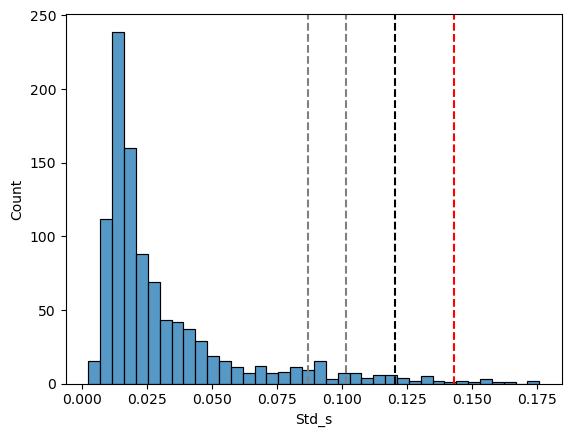

In [212]:
# Plotting the distribution of standard deviations, with 95th, 97.5th and 99th percentiles
std_925_CDS = np.nanpercentile(s_bymut_CDS['Std_s'], 92.5)
std_95_CDS = np.nanpercentile(s_bymut_CDS['Std_s'], 95)
std_975_CDS = np.nanpercentile(s_bymut_CDS['Std_s'], 97.5)
std_99_CDS = np.nanpercentile(s_bymut_CDS['Std_s'], 99)

sns.histplot(data=s_bymut_CDS, x='Std_s')
plt.axvline(x=std_925_CDS, linestyle='--', c='grey')
plt.axvline(x=std_95_CDS, linestyle='--', c='grey')
plt.axvline(x=std_975_CDS, linestyle='--', c='black')
plt.axvline(x=std_99_CDS, linestyle='--', c='red')

There seems to be outlier genotypes. The 95th percentile will be used as threshold.

2. nMAD by s estimate

In [215]:
# Computing 95th, 97.5 and 99 percentiles
n_MAD_95_CDS = np.nanpercentile(s_MAD_CDS['n_MAD'], 95)
n_MAD_975_CDS = np.nanpercentile(s_MAD_CDS['n_MAD'], 97.5)
n_MAD_99_CDS = np.nanpercentile(s_MAD_CDS['n_MAD'], 99)

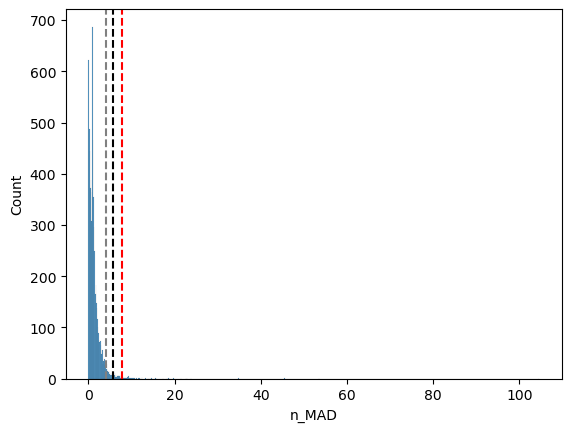

In [216]:
sns.histplot(data=s_MAD_CDS, x='n_MAD')
plt.axvline(x=n_MAD_95_CDS, linestyle='--', c='grey')
plt.axvline(x=n_MAD_975_CDS, linestyle='--', c='black')
plt.axvline(x=n_MAD_99_CDS, linestyle='--', c='red')

We definitely have some outliers! The 95th percentile will be used as threshold, again.

### Filtering out outlier measurements

Within genotypes with std >= 95th percentile, datapoints with nMAD >= 95th percentile are removed.

In [220]:
# Selecting genotypes on which the filtering must be applied
out_df_CDS = s_bymut_CDS[s_bymut_CDS['Std_s'] >= std_95_CDS].copy().reset_index(drop=True)
mut_to_filter_CDS = out_df_CDS['Genotype'].unique()

In [221]:
# Identifying the datapoints to remove
not_filtered_CDS =  s_MAD_CDS[~s_MAD_CDS['Genotype'].isin(mut_to_filter_CDS)].copy()
to_filter_CDS = s_MAD_CDS[s_MAD_CDS['Genotype'].isin(mut_to_filter_CDS)].copy()
to_filter_CDS['To_remove'] = to_filter_CDS['n_MAD'] > n_MAD_95_CDS

Plotting the outlier genotypes

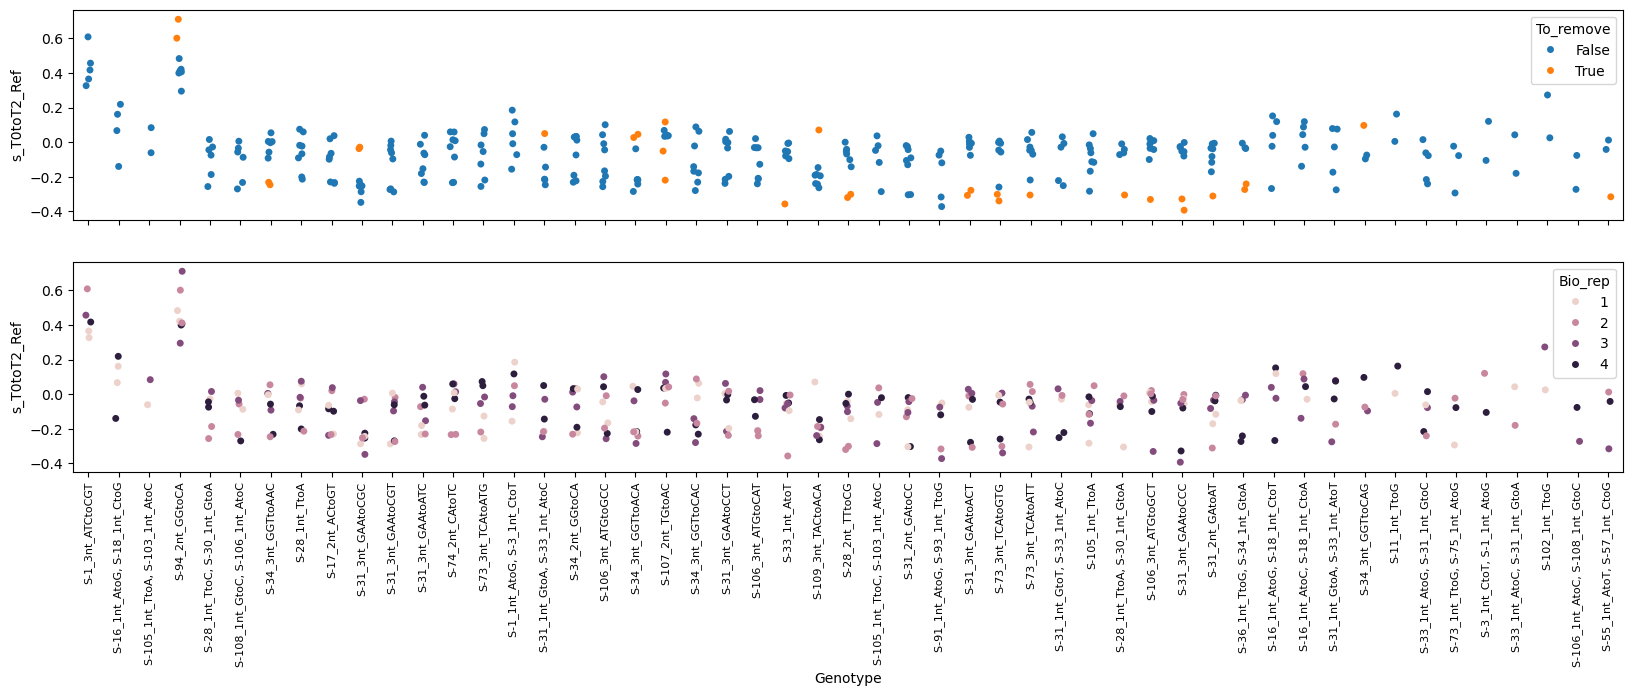

In [223]:
# All variants

fig, axs = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
sns.stripplot(data=to_filter_CDS, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_CDS, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

The relevance of this step seems much less obvious. What does the same graph look like when including only mutations which are part of the spike-in?

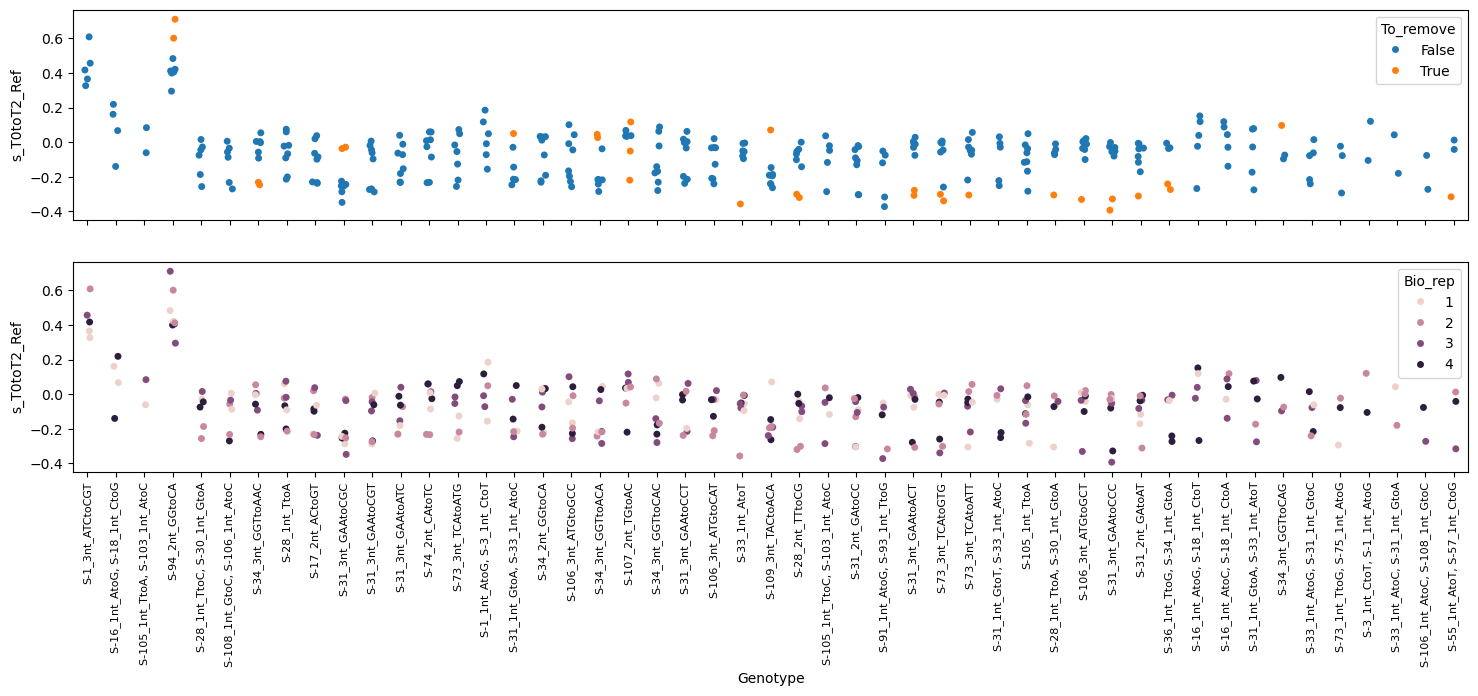

In [225]:
# Only mutations included in the spike-in (substitutions at the chosen codons)

to_filter_F3F4_CDS = to_filter_CDS[to_filter_CDS['In spike-in'] == True].copy().reset_index(drop=True)

fig, axs = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
sns.stripplot(data=to_filter_F3F4_CDS, x='Genotype', y='s_T0toT2_Ref', hue='To_remove', ax=axs[0])
axs[0].tick_params(axis='x', labelrotation=90)

sns.stripplot(data=to_filter_F3F4_CDS, x='Genotype', y='s_T0toT2_Ref', hue='Bio_rep', ax=axs[1])
axs[1].tick_params(axis='x', labelrotation=90, labelsize=8)

The benefit of removing the outliers is not obvious here. They do not seem to be "biological artifacts", such as resistance-conferring secondary mutations, as previously. It will still be performed before testing how many mutations have significant fitness effects (!=0).

In [227]:
# Assembling the corresponding dataset without outliers
out_filtered_CDS = to_filter_CDS[to_filter_CDS['To_remove'] == False].copy().reset_index(drop=True)
out_filtered_CDS = out_filtered_CDS.drop(columns=['To_remove'])
s_no_out_CDS = pd.concat([not_filtered_CDS, out_filtered_CDS]).reset_index(drop=True)

### Testing how many fitness effects are significant

In [229]:
s_med_CDS = s_medians_CDS[s_medians_CDS['In spike-in'] == True].copy().reset_index(drop=True).drop(columns=['s_T0toT1_Ref', 's_T0toT3_Ref'])
s_CDS = s_no_out_CDS[s_no_out_CDS['In spike-in'] == True].copy().reset_index(drop=True)

In [230]:
# Adding min and max s to s_med_CDS
min_CDS = s_CDS[['Genotype', 'Position (codon)', 'Included_position',
                 'In spike-in', 'Mutation types', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position (codon)', 'Included_position',
                                                                               'In spike-in', 'Mutation types'], as_index=False).min()
min_CDS = min_CDS.rename(columns={'s_T0toT2_Ref': 'Min_s'})

max_CDS = s_CDS[['Genotype', 'Position (codon)', 'Included_position',
                 'In spike-in', 'Mutation types', 's_T0toT2_Ref']].groupby(by=['Genotype', 'Position (codon)', 'Included_position',
                                                                               'In spike-in', 'Mutation types'], as_index=False).max()
max_CDS = max_CDS.rename(columns={'s_T0toT2_Ref': 'Max_s'})

s_med_CDS = pd.merge(s_med_CDS, min_CDS, on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='outer')
s_med_CDS = pd.merge(s_med_CDS, max_CDS, on=['Genotype', 'Position (codon)', 'Included_position', 'In spike-in', 'Mutation types'], how='outer')

In [231]:
s_med_CDS['not_zero_p-val'] = np.nan
s_med_CDS['n_observed'] = np.nan

for row in range(s_med_CDS.shape[0]):
    current_mut = s_med_CDS.at[row, 'Genotype']
    data_subset = s_CDS[s_CDS['Genotype'] == current_mut].copy().reset_index(drop=True)
    n_obs = data_subset.shape[0]
    s_med_CDS.at[row, 'n_observed'] = n_obs
    t_test = stats.ttest_1samp(data_subset['s_T0toT2_Ref'], 0, nan_policy='omit')
    s_med_CDS.at[row, 'not_zero_p-val'] = t_test.pvalue

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\scipy\stats\_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\scipy\stats\_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [232]:
s_med_CDS[s_med_CDS['not_zero_p-val'].isna()]

,Genotype,Position (codon),Included_position,In spike-in,Mutation types,N_T0,N_T3,Median_s_T0toT2,Min_s,Max_s,not_zero_p-val,n_observed
70,"S-105_1nt_TtoG, S-103_1nt_AtoT",99,True,True,['Substitution'],6179.0,36.0,-0.039267,-0.039267,-0.039267,NaN,1.0
142,"S-109_1nt_TtoC, S-111_1nt_CtoA",101,True,True,['Substitution'],1679.0,9216.0,0.393311,0.393311,0.393311,NaN,1.0
145,"S-109_1nt_TtoG, S-111_1nt_CtoA",101,True,True,['Substitution'],1300.0,8184.0,0.357009,0.357009,0.357009,NaN,1.0
146,"S-109_1nt_TtoG, S-111_1nt_CtoG",101,True,True,['Substitution'],733.0,5402.0,0.387732,0.387732,0.387732,NaN,1.0
504,"S-30_1nt_GtoT, S-28_1nt_TtoA",74,True,True,['Substitution'],134.0,3.0,0.000136,0.000136,0.000136,NaN,1.0
712,"S-73_1nt_TtoC, S-75_1nt_AtoC",89,True,True,['Substitution'],2.0,293.0,0.685753,0.685753,0.685753,NaN,1.0
845,"S-91_1nt_AtoC, S-93_1nt_TtoG",95,True,True,['Substitution'],33.0,154.0,0.308087,0.308087,0.308087,NaN,1.0
855,S-91_2nt_ACtoCG,95,True,True,['Substitution'],11.0,128.0,0.387611,0.387611,0.387611,NaN,1.0


In [233]:
# Dropping NaNs for the Benjamini-Hochberg correction
s_med_na = s_med_CDS[s_med_CDS['not_zero_p-val'].isna()].copy().reset_index(drop=True)
s_med_CDS = s_med_CDS.dropna(subset=['not_zero_p-val']).reset_index(drop=True)
s_med_CDS['not_zero_FDR'] = stats.false_discovery_control(s_med_CDS['not_zero_p-val'])

In [234]:
s_med_CDS[s_med_CDS['not_zero_FDR'] < 0.05].shape[0]

758

Among the ~1000 CDS mutants selected, 758 have a significant effect on fitness!

In [236]:
s_med_CDS[s_med_CDS['not_zero_FDR'] < 0.05].sort_values(by='Median_s_T0toT2')

,Genotype,Position (codon),Included_position,In spike-in,Mutation types,N_T0,N_T3,Median_s_T0toT2,Min_s,Max_s,not_zero_p-val,n_observed,not_zero_FDR
531,S-31_3nt_GAAtoCGC,75,True,True,['Substitution'],603.0,1.0,-0.248626,-0.348204,-0.225734,2.344227e-05,6.0,4.183008e-05
759,"S-75_1nt_AtoC, S-73_1nt_TtoG",89,True,True,['Substitution'],575.0,1.5,-0.230926,-0.325031,-0.098449,1.779236e-02,4.0,2.388904e-02
586,S-34_3nt_GGTtoACA,76,True,True,['Substitution'],397.5,1.0,-0.216945,-0.285138,-0.038749,2.035977e-03,6.0,3.122265e-03
152,S-109_3nt_TACtoACA,101,True,True,['Substitution'],4316.0,9.5,-0.192940,-0.263656,-0.147015,9.720676e-06,7.0,1.786118e-05
502,"S-31_1nt_GtoA, S-33_1nt_AtoC",75,True,True,['Substitution'],323.5,1.0,-0.179153,-0.246558,-0.029806,1.193257e-02,5.0,1.643510e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,"S-19_1nt_TtoC, S-21_1nt_TtoA",71,True,True,['Substitution'],2389.0,15570.0,0.401839,0.392847,0.410832,1.424451e-02,2.0,1.949714e-02
732,S-73_3nt_TCAtoCGG,89,True,True,['Substitution'],1662.5,12489.5,0.403547,0.383358,0.418842,9.026384e-12,8.0,7.470111e-11
912,S-94_2nt_GGtoCA,96,True,True,['Substitution'],21.0,203.0,0.416346,0.294436,0.482813,1.647086e-05,6.0,2.972184e-05
394,S-1_3nt_ATCtoCGT,65,True,True,['Substitution'],48.0,193.0,0.416588,0.326074,0.608146,8.777792e-04,5.0,1.406791e-03


Considering the expression-fitness function which we have measured experimentally, it is unlikely that the deleterious effects which are significant are real. They are probably artifacts related to secondary mutations in the WT.  

## Exporting the selection coefficient estimates for CDS mutations in 5-FC

In [239]:
s_med_CDS = pd.concat([s_med_CDS, s_med_na])

In [240]:
# Median s for F3F4 mutations, with p-values (t-test to see if diff from 0)
s_med_CDS.to_csv("Supp_data/median_s_CDS.csv", index=False)

# Final data, per library (only 5-FC and no spike-ins)
s_no_out_CDS.to_csv("Supp_data/s_150_CDS_5FC_no_out.csv", index=False)

## Saving figures S10 and S11

### S10 Fig

In [243]:
# Renaming columns
to_filter_F3F4 = to_filter_F3F4.rename(columns={'To_remove': 'Removed', 'Bio_rep': 'Transformation'})

# Changing True/False For Yes/No
to_filter_F3F4['Removed'] = to_filter_F3F4['Removed'].apply(lambda x: 'Yes' if x else 'No')

In [244]:
# Renaming the genotypes
for row in to_filter_F3F4.index:
    current_mut = to_filter_F3F4.at[row, 'Genotype']
    mut_type = current_mut[0]
    position = int(current_mut.split('_')[0].split('-')[1])
    mut_char = current_mut.split('_')[2]

    if mut_type == 'I':
        new_pos = position + 1 - 205
    else:
        new_pos = position - 205

    new_mut = f'{mut_type}_{new_pos}_{mut_char}'
    to_filter_F3F4.at[row, 'Fig_genotype'] = new_mut

In [245]:
to_filter_F3F4

,Genotype,Position,In F3F4,Mutation type,Alias,Transformation,Tech_rep,To_ignore,N_T0,N_T3,s_T0toT1_Ref,s_T0toT2_Ref,s_T0toT3_Ref,Median_s_T0toT2,Abs_med_s_T0toT2,MAD_s_T0toT2,n_MAD,Removed,Fig_genotype
0,S-126_1nt_TtoG,126,True,Substitution,15,2,B,False,279,2.0,-0.026761,0.003951,-0.031943,-0.001680,0.005631,0.007327,0.768490,No,S_-79_TtoG
1,I-192_1nt_-toC,192,True,Insertion,15,2,B,False,303,3.0,0.005033,0.029192,-0.015658,-0.017566,0.046758,0.024609,1.900068,No,I_-12_-toC
2,I-116_1nt_-toC,116,True,Insertion,15,2,B,False,167,5.0,0.017873,-0.033390,0.008084,-0.006328,0.027062,0.018250,1.482798,No,I_-88_-toC
3,S-172_1nt_GtoC,172,True,Substitution,15,2,B,False,239,684.0,0.093930,0.198646,0.241559,0.014663,0.183983,0.039653,4.639807,Yes,S_-33_GtoC
4,S-139_1nt_TtoA,139,True,Substitution,15,2,B,False,431,6.0,-0.038908,-0.023206,-0.012724,-0.013245,0.009961,0.008254,1.206798,No,S_-66_TtoA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,S-78_1nt_GtoA,78,True,Substitution,13,1,B,True,618,15.0,0.002133,-0.010678,-0.072679,-0.000219,0.010459,0.011322,0.923805,No,S_-127_GtoA
142,S-151_1nt_GtoA,151,True,Substitution,13,1,B,True,644,40.0,0.006241,0.004429,-0.032924,-0.008945,0.013375,0.007907,1.691472,No,S_-54_GtoA
143,I-117_1nt_-toT,117,True,Insertion,13,1,B,True,544,7.0,-0.010309,-0.002449,-0.093315,-0.001777,0.000672,0.004533,0.148235,No,I_-87_-toT
144,S-192_1nt_AtoG,192,True,Substitution,13,1,B,True,536,19.0,0.006341,-0.015339,-0.059957,-0.009194,0.006145,0.007164,0.857809,No,S_-13_AtoG


In [246]:
to_filter_F3F4 = to_filter_F3F4.rename(columns={'Transformation replicate': 'Transformation'})

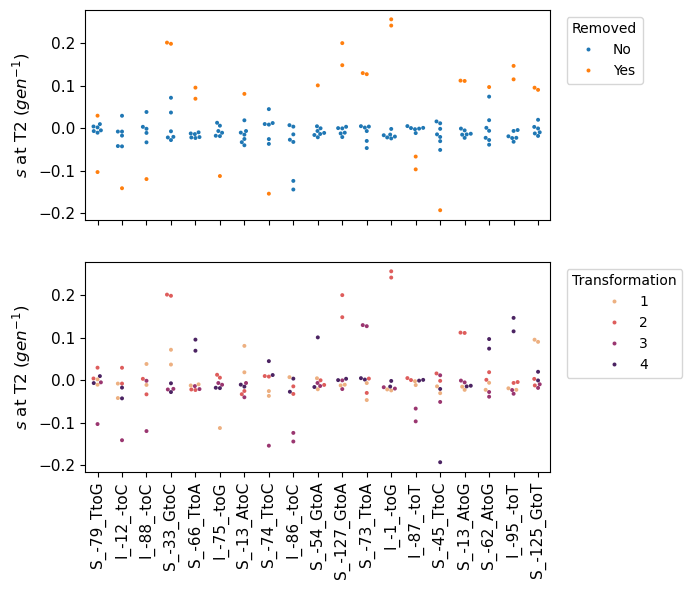

In [247]:
# S10 Fig: Removal of outliers for 
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams['savefig.dpi'] = 600


fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
removed = sns.swarmplot(data=to_filter_F3F4, x='Fig_genotype', y='s_T0toT2_Ref', hue='Removed', size=2.85, ax=axs[0])
sns.move_legend(removed, "upper left", bbox_to_anchor=(1.02, 1))
axs[0].set_ylabel(r"$s$ at T2 ($gen^{-1}$)")

transfos = sns.swarmplot(data=to_filter_F3F4, x='Fig_genotype', y='s_T0toT2_Ref', hue='Transformation', size=2.85, ax=axs[1], palette='flare')
axs[1].tick_params(axis='x', labelrotation=90)
axs[1].set_xlabel('')
sns.move_legend(transfos, "upper left", bbox_to_anchor=(1.02, 1))
axs[1].set_ylabel(r"$s$ at T2 ($gen^{-1}$)")

FigS10 = plt.gcf()
FigS10.savefig('Supp_figs/S10Fig.tiff', bbox_inches='tight')

In [248]:
to_filter_F3F4

,Genotype,Position,In F3F4,Mutation type,Alias,Transformation,Tech_rep,To_ignore,N_T0,N_T3,s_T0toT1_Ref,s_T0toT2_Ref,s_T0toT3_Ref,Median_s_T0toT2,Abs_med_s_T0toT2,MAD_s_T0toT2,n_MAD,Removed,Fig_genotype
0,S-126_1nt_TtoG,126,True,Substitution,15,2,B,False,279,2.0,-0.026761,0.003951,-0.031943,-0.001680,0.005631,0.007327,0.768490,No,S_-79_TtoG
1,I-192_1nt_-toC,192,True,Insertion,15,2,B,False,303,3.0,0.005033,0.029192,-0.015658,-0.017566,0.046758,0.024609,1.900068,No,I_-12_-toC
2,I-116_1nt_-toC,116,True,Insertion,15,2,B,False,167,5.0,0.017873,-0.033390,0.008084,-0.006328,0.027062,0.018250,1.482798,No,I_-88_-toC
3,S-172_1nt_GtoC,172,True,Substitution,15,2,B,False,239,684.0,0.093930,0.198646,0.241559,0.014663,0.183983,0.039653,4.639807,Yes,S_-33_GtoC
4,S-139_1nt_TtoA,139,True,Substitution,15,2,B,False,431,6.0,-0.038908,-0.023206,-0.012724,-0.013245,0.009961,0.008254,1.206798,No,S_-66_TtoA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,S-78_1nt_GtoA,78,True,Substitution,13,1,B,True,618,15.0,0.002133,-0.010678,-0.072679,-0.000219,0.010459,0.011322,0.923805,No,S_-127_GtoA
142,S-151_1nt_GtoA,151,True,Substitution,13,1,B,True,644,40.0,0.006241,0.004429,-0.032924,-0.008945,0.013375,0.007907,1.691472,No,S_-54_GtoA
143,I-117_1nt_-toT,117,True,Insertion,13,1,B,True,544,7.0,-0.010309,-0.002449,-0.093315,-0.001777,0.000672,0.004533,0.148235,No,I_-87_-toT
144,S-192_1nt_AtoG,192,True,Substitution,13,1,B,True,536,19.0,0.006341,-0.015339,-0.059957,-0.009194,0.006145,0.007164,0.857809,No,S_-13_AtoG


### S11 Fig

In [250]:
# Combining all selection coefficients with and without 5-FC (keepin sample ids)
FC_to_comp = s_no_out[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Bio_rep', 'Tech_rep',
                      's_T0toT2_Ref']].copy()
FC_to_comp['samp_id'] = FC_to_comp['Bio_rep'].astype('str') + FC_to_comp['Tech_rep']
FC_to_comp['Condition'] = '5-FC'

no_to_comp = s_no_5FC[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Bio_rep', 'Tech_rep',
                      's_T0toT2_Ref']].copy()
# Samples with spike-ins have already been removed
no_to_comp['samp_id'] = no_to_comp['Bio_rep'].astype('str') + no_to_comp['Tech_rep']
no_to_comp['Condition'] = 'No 5-FC'

s_fig_comp = pd.concat([FC_to_comp, no_to_comp]).reset_index(drop=True)

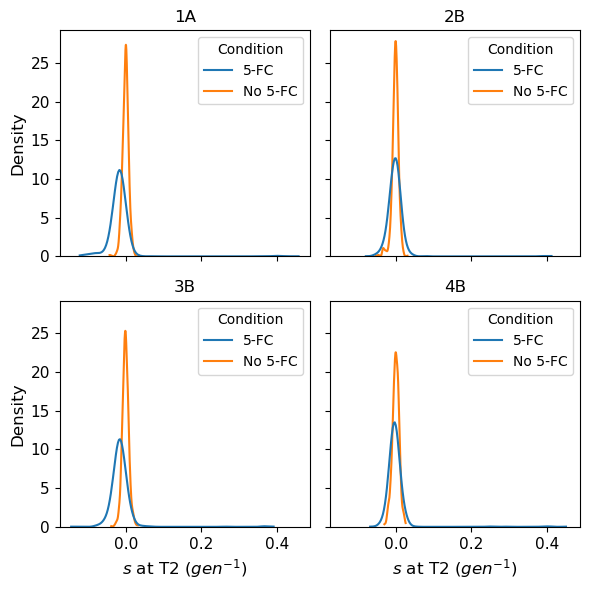

In [251]:
# Making the figure
fig, axs = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)

order_samp = ['1A', '2B', '3B', '4B']
ax_row = 0
ax_col = 0

for fig_num in range(4):
    lib_id = order_samp[fig_num]
    data_subset = s_fig_comp[s_fig_comp['samp_id'] == lib_id].copy().reset_index(drop=True)
    sns.kdeplot(data=data_subset, x='s_T0toT2_Ref', hue='Condition', ax=axs[ax_row, ax_col], cut=0)
    axs[ax_row, ax_col].set_title(f'{lib_id}')

    if ax_col == 1:
        ax_row += 1
        ax_col = 0
    else:
        ax_col += 1

axs[1,0].set_xlabel(r"$s$ at T2 ($gen^{-1}$)")
axs[1,1].set_xlabel(r"$s$ at T2 ($gen^{-1}$)")

plt.tight_layout()

FigS11 = plt.gcf()
FigS11.savefig('Supp_figs/S11Fig.tiff', bbox_inches='tight')

### S13B Fig

Redoing the comparison between samples with and without spike-ins, for the F3-F4 pools

In [254]:
# Adding a column identifying F3-F4 and CDS variants (and removing secondary mutations in the promoter)
medians_merged = medians_merged[medians_merged['FCY1_position'] >= -153].copy().reset_index(drop=True)
medians_merged['Type of variant'] = medians_merged['In F3F4'].apply(lambda x: 'F3F4' if x else 'CDS')

In [255]:
medians_merged.sort_values(by=['Median_s_T0toT2_Spikes'], ascending=False)

,Genotype,Position,In F3F4,Mutation type,Median_s_T0toT2,Median_s_ignored,Min_s_ignored,Max_s_ignored,FCY1_position,New_nt,To_ignore,Median_s_T0toT2_Spikes,Min_s,Max_s,Type of variant
79,D-240_1nt_Ato-,240,False,Deletion,0.393793,0.393793,0.387733,0.399853,35,-,False,0.545093,0.538683,0.551503,CDS
84,D-248_1nt_Ato-,248,False,Deletion,0.388811,NaN,NaN,NaN,43,-,False,0.511814,0.387535,0.636093,CDS
76,D-229_1nt_Cto-,229,False,Deletion,0.392502,0.392502,0.376806,0.408197,24,-,False,0.507794,0.470717,0.544871,CDS
81,D-242_1nt_Ato-,242,False,Deletion,0.372719,NaN,NaN,NaN,37,-,False,0.476802,0.476802,0.476802,CDS
437,I-222_1nt_-toG,222,False,Insertion,0.381753,NaN,NaN,NaN,18,G,False,0.457564,0.457564,0.457564,CDS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,S-298_1nt_TtoA,298,False,Substitution,-0.011824,NaN,NaN,NaN,93,A,NaN,NaN,NaN,NaN,CDS
949,S-298_1nt_TtoG,298,False,Substitution,-0.030365,-0.036543,-0.050243,-0.022844,93,G,NaN,NaN,NaN,NaN,CDS
951,S-300_1nt_CtoA,300,False,Substitution,-0.079218,NaN,NaN,NaN,95,A,NaN,NaN,NaN,NaN,CDS
954,S-309_1nt_GtoT,309,False,Substitution,-0.103367,NaN,NaN,NaN,104,T,NaN,NaN,NaN,NaN,CDS


In [256]:
# Preparing another version of the dataframe for violinplots
medians_violins = pd.melt(medians_merged[['Genotype', 'Median_s_ignored', 'Median_s_T0toT2_Spikes', 'Type of variant']].copy(),
                         id_vars=['Genotype', 'Type of variant'], value_vars=['Median_s_ignored', 'Median_s_T0toT2_Spikes'],
                         value_name='Median s', var_name='Libraries')
# Reformatting the libraries column
lib_type_dict = {'Median_s_ignored': 'Only F3F4', 'Median_s_T0toT2_Spikes': 'With CSM'}
medians_violins['Libraries'] = medians_violins['Libraries'].apply(lambda x: lib_type_dict[x])

In [257]:
medians_violins

,Genotype,Type of variant,Libraries,Median s
0,D-106_1nt_Gto-,F3F4,Only F3F4,-0.008121
1,D-107_1nt_Cto-,F3F4,Only F3F4,0.000037
2,D-108_1nt_Gto-,F3F4,Only F3F4,-0.002439
3,D-109_1nt_Ato-,F3F4,Only F3F4,-0.013795
4,D-112_1nt_Tto-,F3F4,Only F3F4,0.006181
...,...,...,...,...
2203,S-98_1nt_TtoC,F3F4,With CSM,-0.032351
2204,S-98_1nt_TtoG,F3F4,With CSM,0.000716
2205,S-99_1nt_TtoA,F3F4,With CSM,-0.007090
2206,S-99_1nt_TtoC,F3F4,With CSM,0.017268


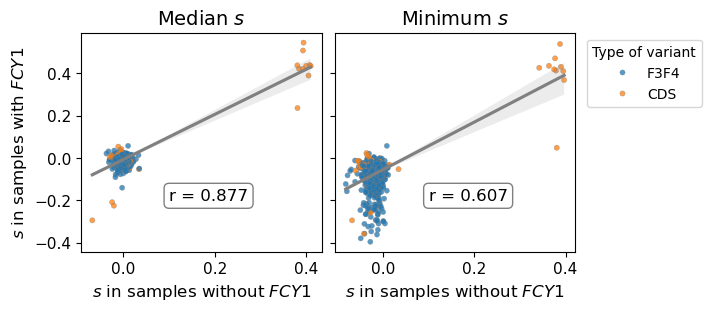

In [258]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

#violins_s = sns.violinplot(data=medians_violins[medians_violins['Var_type'] == 'F3F4'], x='Libraries', y='Median s',
                           #hue='Var_type', ax=axs[0], cut=0, alpha=0.95, edgecolor='grey', legend=False)

sns.scatterplot(data=medians_merged, x='Median_s_ignored', y='Median_s_T0toT2_Spikes', hue='Type of variant', ax=axs[0], edgecolor='grey', s=14,
                alpha=0.75, legend=False)
sns.regplot(data=medians_merged, x='Median_s_ignored', y='Median_s_T0toT2_Spikes', ax=axs[0], color='grey', scatter=False)
calc_1 = medians_merged.dropna(subset=['Median_s_ignored', 'Median_s_T0toT2_Spikes']).reset_index(drop=True)
pearson_1 = stats.pearsonr(calc_1['Median_s_ignored'], calc_1['Median_s_T0toT2_Spikes'])
axs[0].annotate(r"r = "f'{round(pearson_1[0], 3)}',
                (0.1, -0.2), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
axs[0].set_title(r"Median $s$", fontsize=14)
axs[0].set_ylabel(r"$s$ in samples with $\it{FCY1}$")
axs[0].set_xlabel(r"$s$ in samples without $\it{FCY1}$")

scatter_min = sns.scatterplot(data=medians_merged, x='Min_s_ignored', y='Min_s', hue='Type of variant', ax=axs[1], edgecolor='grey', s=14, alpha=0.75)
sns.regplot(data=medians_merged, x='Min_s_ignored', y='Min_s', ax=axs[1], color='grey', scatter=False)
calc_2 = medians_merged.dropna(subset=['Min_s_ignored', 'Min_s']).reset_index(drop=True)
pearson_2 = stats.pearsonr(calc_2['Min_s_ignored'], calc_2['Min_s'])
axs[1].annotate(r"r = "f'{round(pearson_2[0], 3)}',
                (0.1, -0.2), bbox=dict(boxstyle='round', fc='w', alpha=0.5), fontsize=12)
sns.move_legend(scatter_min, "upper left", bbox_to_anchor=(1.02, 1))
axs[1].set_title(r"Minimum $s$", fontsize=14)
axs[1].set_xlabel(r"$s$ in samples without $\it{FCY1}$")

FigS13B = plt.gcf()
FigS13B.savefig('Supp_figs/S13BFig.tiff', bbox_inches='tight')